# WEATHER PREDICTION - COMPLETE PROJECT

### DATA UNDERSTANDING
### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### Load Dataset

Note: Naming of the columns is also fixed here.

In [2]:
df = pd.read_csv('open-meteo-cesena2015-2025.csv')
df.head()

,time,temperature_2m (Â°C),relative_humidity_2m (%),precipitation (mm),surface_pressure (hPa),soil_temperature_0_to_7cm (Â°C),wind_speed_10m (km/h),wind_direction_10m (Â°),wind_gusts_10m (km/h),dew_point_2m (Â°C),apparent_temperature (Â°C),cloud_cover (%),pressure_msl (hPa)
0,2015-01-01T00:00,-2.8,77,0.0,1026.5,1.5,8.2,319,16.6,-6.3,-6.9,8,1032.6
1,2015-01-01T06:00,-3.6,75,0.0,1027.9,1.1,13.8,290,30.6,-7.4,-8.6,17,1034.0
2,2015-01-01T12:00,2.1,69,0.0,1028.9,1.7,15.7,323,28.8,-2.9,-2.7,40,1034.9
3,2015-01-01T18:00,1.8,75,0.0,1028.7,2.7,9.7,297,16.6,-2.3,-2.1,58,1034.7
4,2015-01-02T00:00,-2.4,76,0.0,1028.4,1.9,9.7,272,16.6,-6.0,-6.7,4,1034.5


In [3]:
# FIX: Clean column names (replace encoding issues)
df.columns = df.columns.str.replace('Â°', '°')

print(f'Shape: {df.shape}')
for col in df.columns:
    print(f'- {col}')

Shape: (16072, 13)
- time
- temperature_2m (°C)
- relative_humidity_2m (%)
- precipitation (mm)
- surface_pressure (hPa)
- soil_temperature_0_to_7cm (°C)
- wind_speed_10m (km/h)
- wind_direction_10m (°)
- wind_gusts_10m (km/h)
- dew_point_2m (°C)
- apparent_temperature (°C)
- cloud_cover (%)
- pressure_msl (hPa)


### Data Info

In [4]:
print('Dataset Information:')
df.info()
print('\nMissing Values:')
print(df.isnull().sum())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 16072 entries, 0 to 16071
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   time                            16072 non-null  str    
 1   temperature_2m (°C)             16072 non-null  float64
 2   relative_humidity_2m (%)        16072 non-null  int64  
 3   precipitation (mm)              16072 non-null  float64
 4   surface_pressure (hPa)          16072 non-null  float64
 5   soil_temperature_0_to_7cm (°C)  16072 non-null  float64
 6   wind_speed_10m (km/h)           16072 non-null  float64
 7   wind_direction_10m (°)          16072 non-null  int64  
 8   wind_gusts_10m (km/h)           16072 non-null  float64
 9   dew_point_2m (°C)               16072 non-null  float64
 10  apparent_temperature (°C)       16072 non-null  float64
 11  cloud_cover (%)                 16072 non-null  int64  
 12  pressure_msl (hPa)    

There is no missing data, therefore there is no need for imputation. However, all data types are numeric except time. It must be converted to date time.

Note: In Colab, 'time' data type is shown as str. In pandas, object and string type are very similar but not the same. Object type uses pointers to store the string variables. Different versions of pandas library can cause different results in colab and jupyter. This difference is not very important in this project.

### Statistical Summary

In [5]:
df.describe()

,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),surface_pressure (hPa),soil_temperature_0_to_7cm (°C),wind_speed_10m (km/h),wind_direction_10m (°),wind_gusts_10m (km/h),dew_point_2m (°C),apparent_temperature (°C),cloud_cover (%),pressure_msl (hPa)
count,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000
mean,14.732199,74.189584,0.568330,1010.444662,15.532305,8.494823,191.064211,18.685727,9.511797,13.721323,49.727227,1016.098550
std,8.465981,18.689604,1.995211,7.727320,8.381555,4.836949,94.678053,9.991210,6.319684,10.044394,41.216554,7.812537
min,-8.500000,17.000000,0.000000,970.100000,-1.900000,0.000000,1.000000,1.100000,-16.800000,-12.800000,0.000000,975.700000
25%,8.000000,60.000000,0.000000,1006.000000,8.600000,5.300000,103.000000,11.500000,5.000000,5.700000,4.000000,1011.500000
50%,14.200000,77.000000,0.000000,1010.200000,14.900000,7.500000,216.000000,16.600000,9.700000,13.100000,46.000000,1015.800000
75%,21.000000,91.000000,0.000000,1014.900000,21.900000,10.600000,266.000000,23.800000,14.600000,21.500000,97.000000,1020.600000
max,40.800000,100.000000,28.600000,1036.800000,37.400000,47.500000,360.000000,99.700000,24.900000,39.800000,100.000000,1042.800000


---
## Feature Engineering
### Daily Aggregation
**Converting 6-hourly measurements (00:00, 06:00, 12:00, 18:00) to daily data:**
- Temperature: Extract daily MAX and MIN
- Precipitation: SUM (total daily rainfall)
- Wind gusts: MAX (captures extreme events)
- Other variables: MEAN (daily average)

In [6]:
# Convert time to datetime
df['time'] = pd.to_datetime(df['time'])

# Extract date for grouping
df['date'] = df['time'].dt.date

print(f'Original dataset shape: {df.shape}')
print(f'Measurements per day: {len(df) // df["date"].nunique()}')
df.head()

Original dataset shape: (16072, 14)
Measurements per day: 4


,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),surface_pressure (hPa),soil_temperature_0_to_7cm (°C),wind_speed_10m (km/h),wind_direction_10m (°),wind_gusts_10m (km/h),dew_point_2m (°C),apparent_temperature (°C),cloud_cover (%),pressure_msl (hPa),date
0,2015-01-01 00:00:00,-2.8,77,0.0,1026.5,1.5,8.2,319,16.6,-6.3,-6.9,8,1032.6,2015-01-01
1,2015-01-01 06:00:00,-3.6,75,0.0,1027.9,1.1,13.8,290,30.6,-7.4,-8.6,17,1034.0,2015-01-01
2,2015-01-01 12:00:00,2.1,69,0.0,1028.9,1.7,15.7,323,28.8,-2.9,-2.7,40,1034.9,2015-01-01
3,2015-01-01 18:00:00,1.8,75,0.0,1028.7,2.7,9.7,297,16.6,-2.3,-2.1,58,1034.7,2015-01-01
4,2015-01-02 00:00:00,-2.4,76,0.0,1028.4,1.9,9.7,272,16.6,-6.0,-6.7,4,1034.5,2015-01-02


In [7]:
# Define aggregation rules for each column
agg_dict = {
    # Temperature: max and min
    'temperature_2m (°C)': ['max', 'min'],
    # Apparent temperature: max and min (feels like temperature)
    'apparent_temperature (°C)': ['max', 'min'],
    # Precipitation: sum (total daily rainfall)
    'precipitation (mm)': 'sum',
    # Wind gusts: max (extreme events)
    'wind_gusts_10m (km/h)': 'max',
    # All other variables: mean (daily average)
    'surface_pressure (hPa)': 'mean',
    'pressure_msl (hPa)': 'mean',
    'wind_speed_10m (km/h)': 'mean',
    'soil_temperature_0_to_7cm (°C)': 'mean',
    'relative_humidity_2m (%)': 'mean',
    'dew_point_2m (°C)': 'mean',
    'wind_direction_10m (°)': 'mean',
    'cloud_cover (%)': 'mean'
}

# Perform daily aggregation
df_daily = df.groupby('date').agg(agg_dict)
df_daily.head()

temperature_2m (°C)      apparent_temperature (°C)       \
                           max  min                       max  min   
date                                                                 
2015-01-01                 2.1 -3.6                      -2.1 -8.6   
2015-01-02                 9.9 -3.3                       7.4 -7.7   
2015-01-03                10.4 -1.7                       8.8 -5.4   
2015-01-04                11.5  5.5                       9.4  2.9   
2015-01-05                 9.9 -1.7                       6.2 -5.4   

           precipitation (mm) wind_gusts_10m (km/h) surface_pressure (hPa)  \
                          sum                   max                   mean   
date                                                                         
2015-01-01                0.0                  30.6               1028.000   
2015-01-02                0.0                  16.6               1026.125   
2015-01-03                0.0                  11.2               1019.800   
2015-01-04                0.0                  16.9               1014.125   
2015-01-05                0.5                  15.5               1022.275   

           pressure_msl (hPa) wind_speed_10m (km/h)  \
                         mean                  mean   
date                                                  
2015-01-01           1034.050                11.850   
2015-01-02           1032.100                 6.700   
2015-01-03           1025.750                 6.625   
2015-01-04           1019.925                 9.950   
2015-01-05           1028.225                 8.350   

           soil_temperature_0_to_7cm (°C) relative_humidity_2m (%)  \
                                     mean                     mean   
date                                                                 
2015-01-01                          1.750                    74.00   
2015-01-02                          2.675                    74.00   
2015-01-03                          3.850                    86.75   
2015-01-04                          5.275                    87.00   
2015-01-05                          3.400                    68.50   

           dew_point_2m (°C) wind_direction_10m (°) cloud_cover (%)  
                        mean                   mean            mean  
date                                                                 
2015-01-01            -4.725                 307.25           30.75  
2015-01-02            -2.450                 257.50           48.50  
2015-01-03             1.375                 232.75           85.25  
2015-01-04             5.100                 152.75           18.00  
2015-01-05            -2.475                 254.50            0.75

In [8]:
# Flatten multi-level column names
df_daily.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df_daily.columns]

# Rename columns for clarity
df_daily = df_daily.rename(columns={
    'temperature_2m (°C)_max': 'temp_max (°C)',
    'temperature_2m (°C)_min': 'temp_min (°C)',
    'apparent_temperature (°C)_max': 'apparent_temp_max (°C)',
    'apparent_temperature (°C)_min': 'apparent_temp_min (°C)',
    'precipitation (mm)_sum': 'precipitation_total (mm)',
    'wind_gusts_10m (km/h)_max': 'wind_gusts_max (km/h)',
    'surface_pressure (hPa)_mean': 'surface_pressure_avg (hPa)',
    'pressure_msl (hPa)_mean': 'pressure_msl_avg (hPa)',
    'wind_speed_10m (km/h)_mean': 'wind_speed_avg (km/h)',
    'soil_temperature_0_to_7cm (°C)_mean': 'soil_temp_avg (°C)',
    'relative_humidity_2m (%)_mean': 'humidity_avg (%)',
    'dew_point_2m (°C)_mean': 'dew_point_avg (°C)',
    'wind_direction_10m (°)_mean': 'wind_direction_avg (°)',
    'cloud_cover (%)_mean': 'cloud_cover_avg (%)'
})

df_daily.head()

,temp_max (°C),temp_min (°C),apparent_temp_max (°C),apparent_temp_min (°C),precipitation_total (mm),wind_gusts_max (km/h),surface_pressure_avg (hPa),pressure_msl_avg (hPa),wind_speed_avg (km/h),soil_temp_avg (°C),humidity_avg (%),dew_point_avg (°C),wind_direction_avg (°),cloud_cover_avg (%)
date,,,,,,,,,,,,,,
2015-01-01,2.1,-3.6,-2.1,-8.6,0.0,30.6,1028.000,1034.050,11.850,1.750,74.00,-4.725,307.25,30.75
2015-01-02,9.9,-3.3,7.4,-7.7,0.0,16.6,1026.125,1032.100,6.700,2.675,74.00,-2.450,257.50,48.50
2015-01-03,10.4,-1.7,8.8,-5.4,0.0,11.2,1019.800,1025.750,6.625,3.850,86.75,1.375,232.75,85.25
2015-01-04,11.5,5.5,9.4,2.9,0.0,16.9,1014.125,1019.925,9.950,5.275,87.00,5.100,152.75,18.00
2015-01-05,9.9,-1.7,6.2,-5.4,0.5,15.5,1022.275,1028.225,8.350,3.400,68.50,-2.475,254.50,0.75


In [9]:
# Reset index to make date a column
df_daily = df_daily.reset_index()
df_daily.head()

,date,temp_max (°C),temp_min (°C),apparent_temp_max (°C),apparent_temp_min (°C),precipitation_total (mm),wind_gusts_max (km/h),surface_pressure_avg (hPa),pressure_msl_avg (hPa),wind_speed_avg (km/h),soil_temp_avg (°C),humidity_avg (%),dew_point_avg (°C),wind_direction_avg (°),cloud_cover_avg (%)
0,2015-01-01,2.1,-3.6,-2.1,-8.6,0.0,30.6,1028.000,1034.050,11.850,1.750,74.00,-4.725,307.25,30.75
1,2015-01-02,9.9,-3.3,7.4,-7.7,0.0,16.6,1026.125,1032.100,6.700,2.675,74.00,-2.450,257.50,48.50
2,2015-01-03,10.4,-1.7,8.8,-5.4,0.0,11.2,1019.800,1025.750,6.625,3.850,86.75,1.375,232.75,85.25
3,2015-01-04,11.5,5.5,9.4,2.9,0.0,16.9,1014.125,1019.925,9.950,5.275,87.00,5.100,152.75,18.00
4,2015-01-05,9.9,-1.7,6.2,-5.4,0.5,15.5,1022.275,1028.225,8.350,3.400,68.50,-2.475,254.50,0.75


In [10]:
# Convert date back to datetime for further processing
df_daily['date'] = pd.to_datetime(df_daily['date'])

# Replace the original dataframe
df = df_daily.copy()

print(f'\nAggregated dataset shape: {df.shape}')
print(f'\nNew columns:')
for col in df.columns:
    print(f'  - {col}')

df.head()


Aggregated dataset shape: (4018, 15)

New columns:
  - date
  - temp_max (°C)
  - temp_min (°C)
  - apparent_temp_max (°C)
  - apparent_temp_min (°C)
  - precipitation_total (mm)
  - wind_gusts_max (km/h)
  - surface_pressure_avg (hPa)
  - pressure_msl_avg (hPa)
  - wind_speed_avg (km/h)
  - soil_temp_avg (°C)
  - humidity_avg (%)
  - dew_point_avg (°C)
  - wind_direction_avg (°)
  - cloud_cover_avg (%)


,date,temp_max (°C),temp_min (°C),apparent_temp_max (°C),apparent_temp_min (°C),precipitation_total (mm),wind_gusts_max (km/h),surface_pressure_avg (hPa),pressure_msl_avg (hPa),wind_speed_avg (km/h),soil_temp_avg (°C),humidity_avg (%),dew_point_avg (°C),wind_direction_avg (°),cloud_cover_avg (%)
0,2015-01-01,2.1,-3.6,-2.1,-8.6,0.0,30.6,1028.000,1034.050,11.850,1.750,74.00,-4.725,307.25,30.75
1,2015-01-02,9.9,-3.3,7.4,-7.7,0.0,16.6,1026.125,1032.100,6.700,2.675,74.00,-2.450,257.50,48.50
2,2015-01-03,10.4,-1.7,8.8,-5.4,0.0,11.2,1019.800,1025.750,6.625,3.850,86.75,1.375,232.75,85.25
3,2015-01-04,11.5,5.5,9.4,2.9,0.0,16.9,1014.125,1019.925,9.950,5.275,87.00,5.100,152.75,18.00
4,2015-01-05,9.9,-1.7,6.2,-5.4,0.5,15.5,1022.275,1028.225,8.350,3.400,68.50,-2.475,254.50,0.75


### Create Temporal Features
**Extracting year, month, day and creating season column from daily data**

In [11]:
# Extract temporal features from date
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek

# Create season column
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# this non-numeric column is only added for the plots
df['season'] = df['month'].apply(get_season)

print(f'\nDataset shape: {df.shape}')
df.head()


Dataset shape: (4018, 20)


,date,temp_max (°C),temp_min (°C),apparent_temp_max (°C),apparent_temp_min (°C),precipitation_total (mm),wind_gusts_max (km/h),surface_pressure_avg (hPa),pressure_msl_avg (hPa),wind_speed_avg (km/h),soil_temp_avg (°C),humidity_avg (%),dew_point_avg (°C),wind_direction_avg (°),cloud_cover_avg (%),year,month,day,day_of_week,season
0,2015-01-01,2.1,-3.6,-2.1,-8.6,0.0,30.6,1028.000,1034.050,11.850,1.750,74.00,-4.725,307.25,30.75,2015,1,1,3,Winter
1,2015-01-02,9.9,-3.3,7.4,-7.7,0.0,16.6,1026.125,1032.100,6.700,2.675,74.00,-2.450,257.50,48.50,2015,1,2,4,Winter
2,2015-01-03,10.4,-1.7,8.8,-5.4,0.0,11.2,1019.800,1025.750,6.625,3.850,86.75,1.375,232.75,85.25,2015,1,3,5,Winter
3,2015-01-04,11.5,5.5,9.4,2.9,0.0,16.9,1014.125,1019.925,9.950,5.275,87.00,5.100,152.75,18.00,2015,1,4,6,Winter
4,2015-01-05,9.9,-1.7,6.2,-5.4,0.5,15.5,1022.275,1028.225,8.350,3.400,68.50,-2.475,254.50,0.75,2015,1,5,0,Winter


---
## Exploratory Data Analysis
### Temperature Distribution
**Visualizing temperature distribution with histogram and boxplot by year**

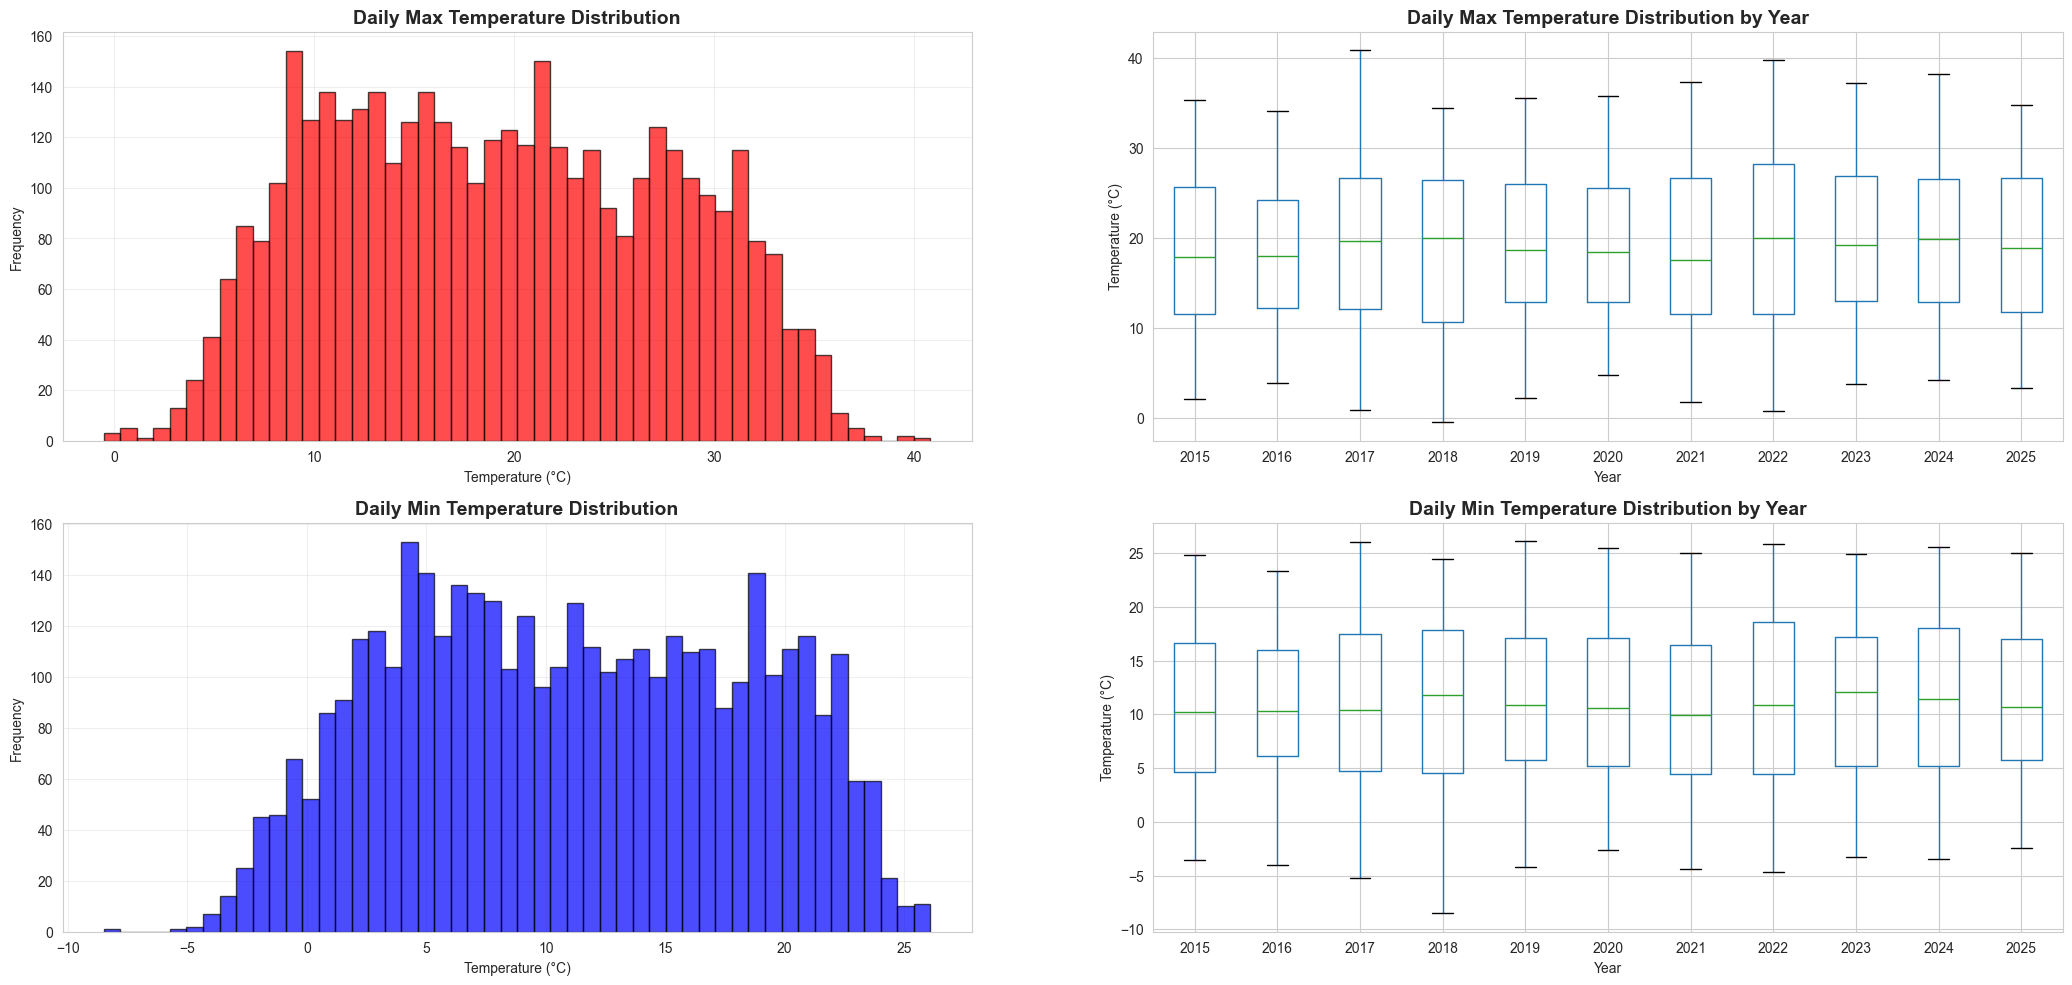

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(25, 12))

# Histogram - using temp_max for distribution analysis
axes[0,0].hist(df['temp_max (°C)'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[0,0].set_title('Daily Max Temperature Distribution', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Temperature (°C)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].grid(True, alpha=0.3)

axes[1, 0].hist(df['temp_min (°C)'], bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[1, 0].set_title('Daily Min Temperature Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Temperature (°C)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Boxplot by year
df.boxplot(column='temp_max (°C)', by='year', ax=axes[0, 1])
axes[0, 1].set_title('Daily Max Temperature Distribution by Year', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Temperature (°C)')
plt.suptitle('')

df.boxplot(column='temp_min (°C)', by='year', ax=axes[1, 1])
axes[1, 1].set_title('Daily Min Temperature Distribution by Year', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Temperature (°C)')
plt.suptitle('')

# plt.tight_layout()
plt.show()

In [13]:
print(f"Daily max temperature range: {df['temp_max (°C)'].min():.1f}°C to {df['temp_max (°C)'].max():.1f}°C")
print(f"Mean daily max temperature: {df['temp_max (°C)'].mean():.1f}°C")
print(f"Daily min temperature range: {df['temp_min (°C)'].min():.1f}°C to {df['temp_min (°C)'].max():.1f}°C")
print(f"Mean daily min temperature: {df['temp_min (°C)'].mean():.1f}°C")

Daily max temperature range: -0.5°C to 40.8°C
Mean daily max temperature: 19.2°C
Daily min temperature range: -8.5°C to 26.1°C
Mean daily min temperature: 11.0°C


### Temperature Over Time
**Time series visualization of temperature trends**

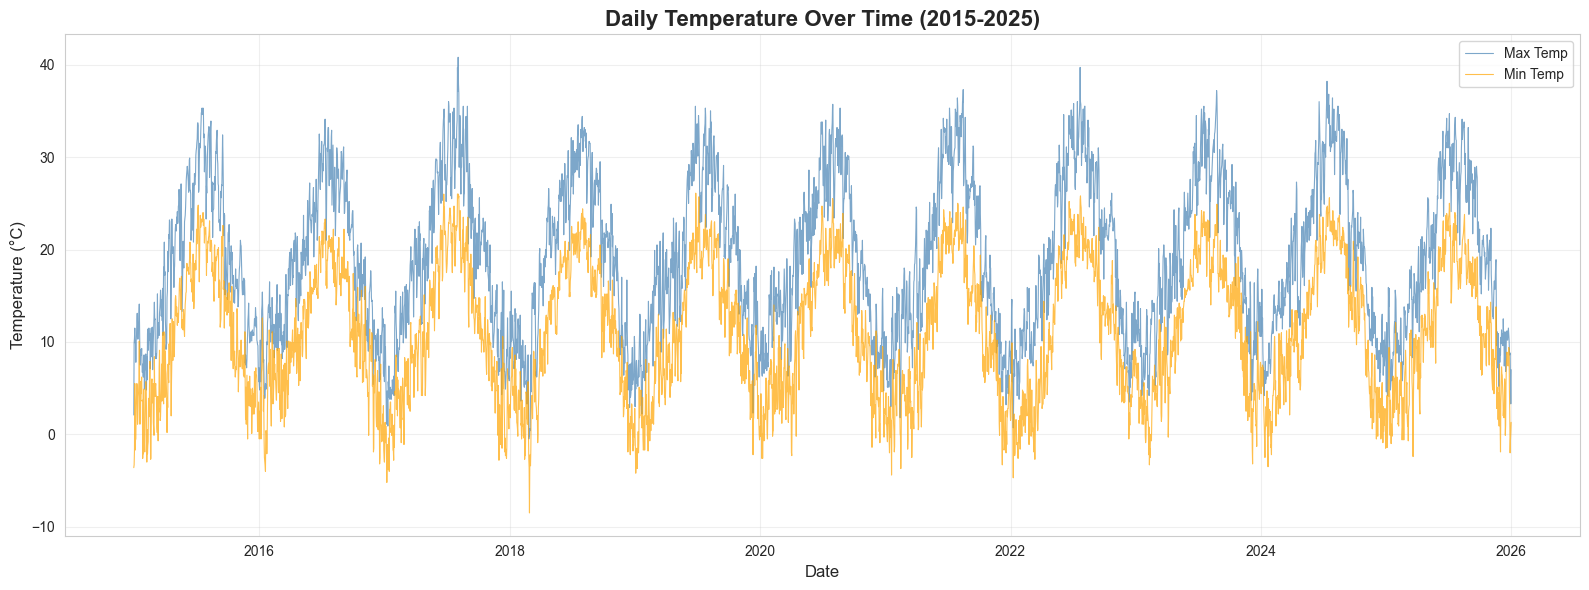

In [14]:
plt.figure(figsize=(16, 6))
plt.plot(df['date'], df['temp_max (°C)'], alpha=0.7, linewidth=0.8, color='steelblue', label='Max Temp')
plt.plot(df['date'], df['temp_min (°C)'], alpha=0.7, linewidth=0.8, color='orange', label='Min Temp')
plt.title('Daily Temperature Over Time (2015-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Get unique years for iteration
years = df['year'].unique().tolist()
years.sort()
years

[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

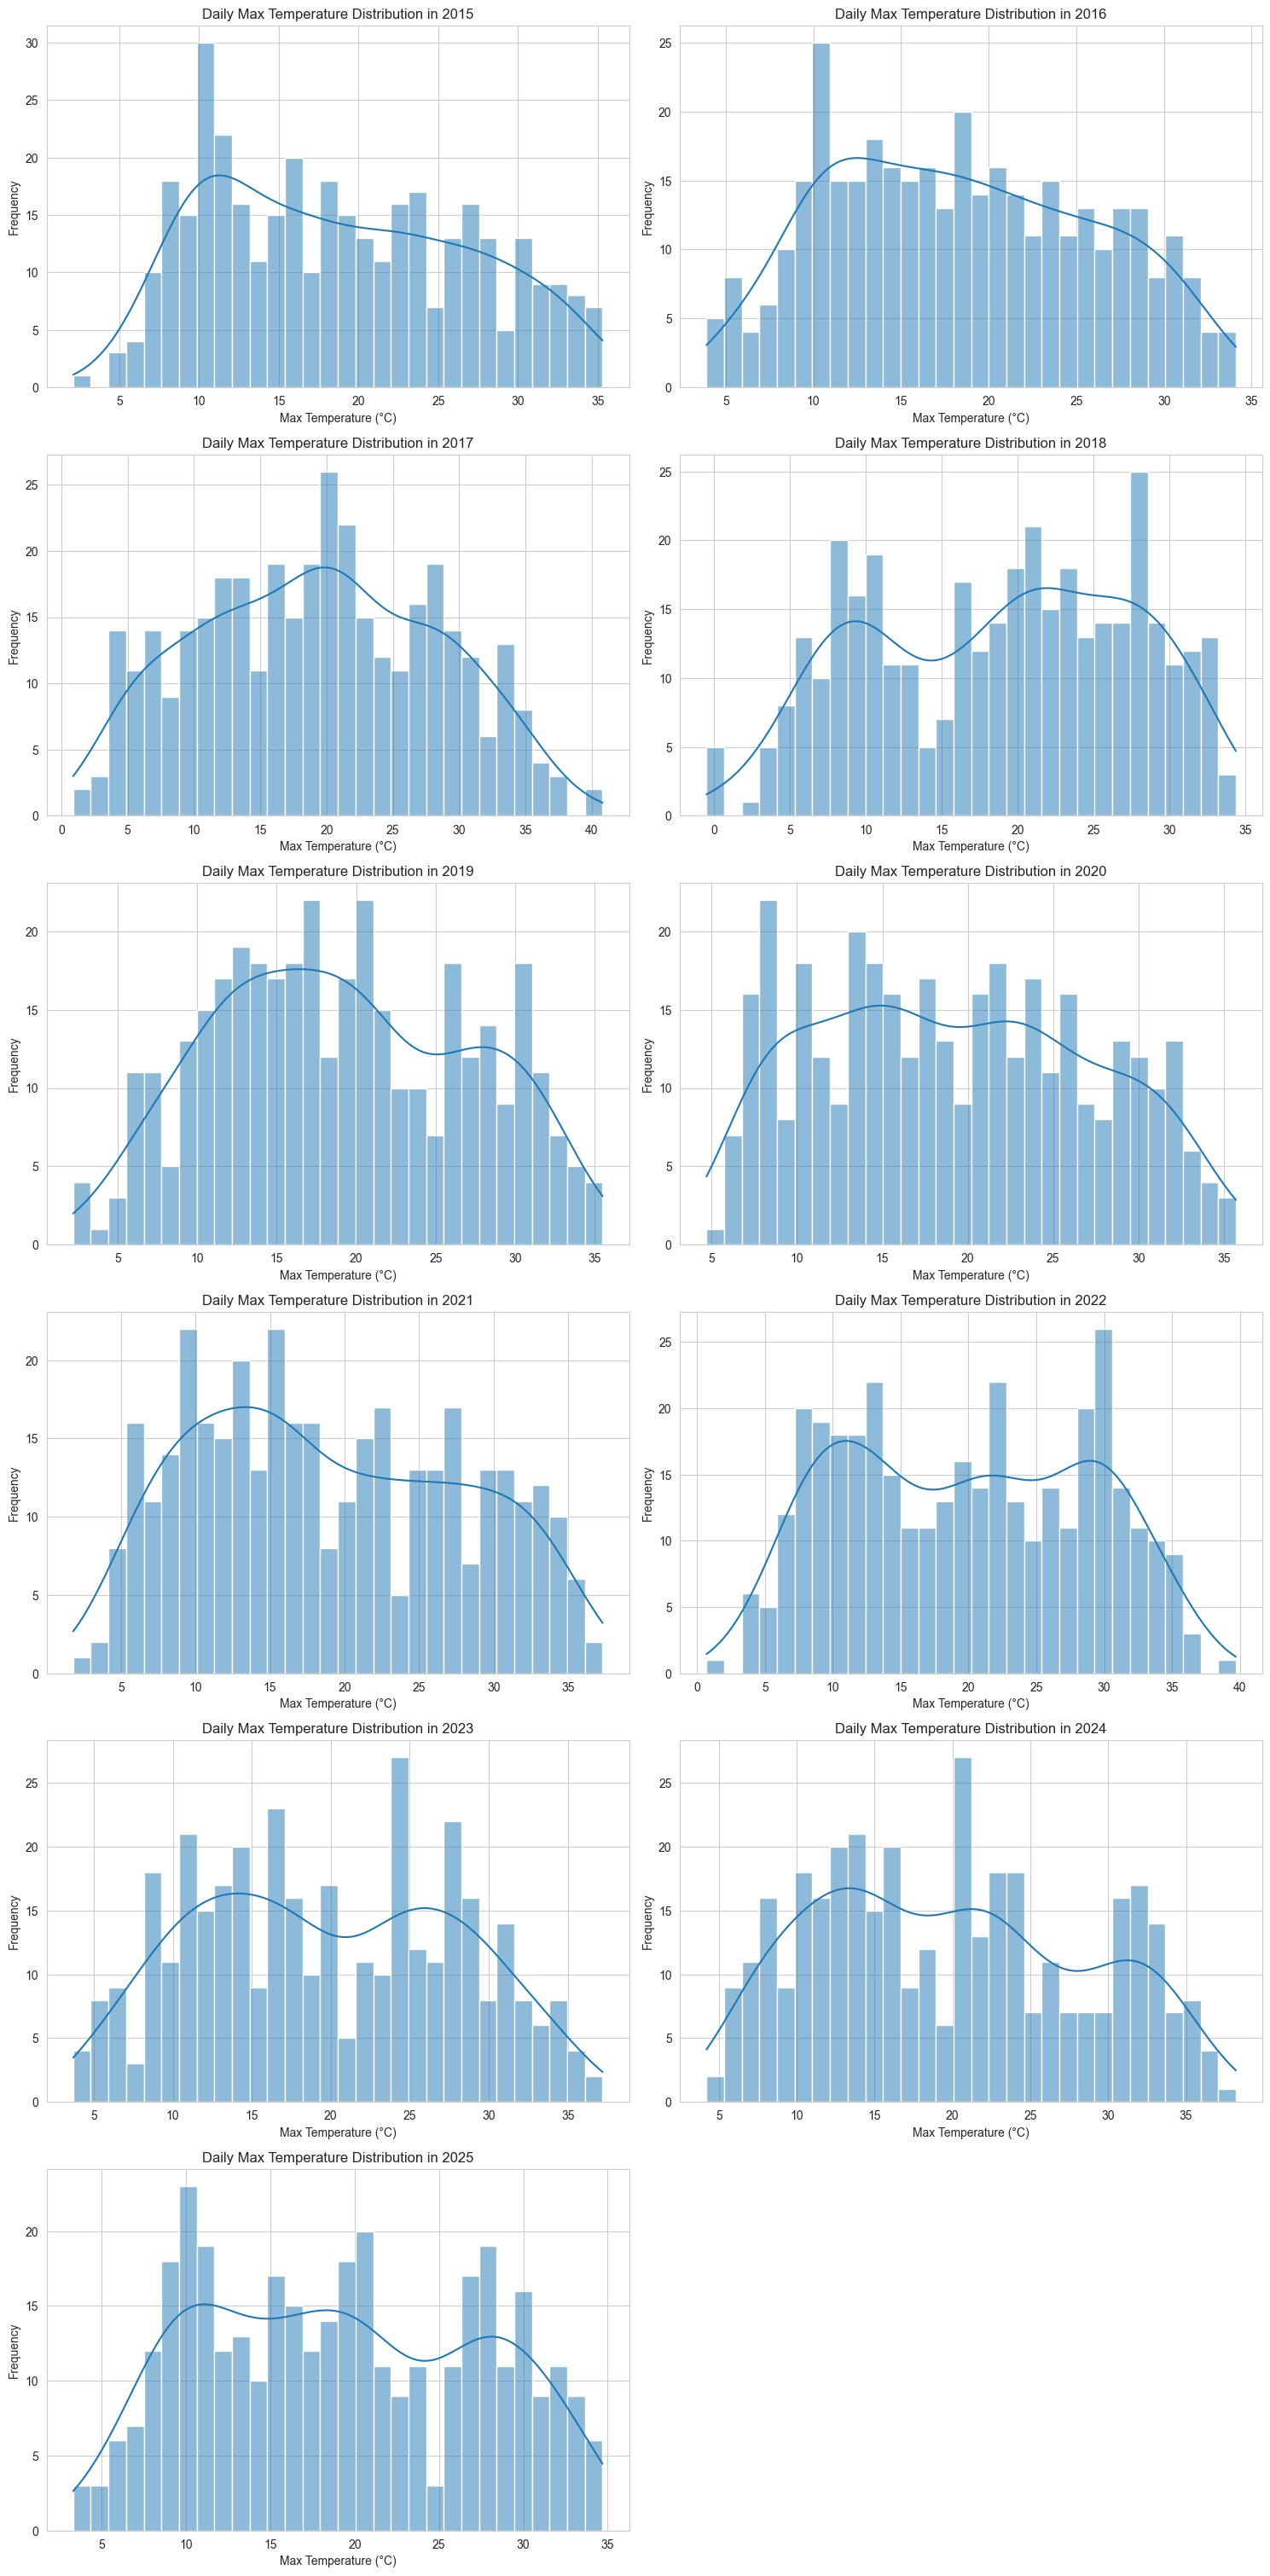

In [16]:
plt.figure(figsize=(15, 5 * len(years)))

for i, year in enumerate(years):
    plt.subplot(len(years), 2, i + 1)
    sns.histplot(df[df['year'] == year]['temp_max (°C)'], kde=True, bins=30)
    plt.title(f'Daily Max Temperature Distribution in {year}')
    plt.xlabel('Max Temperature (°C)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

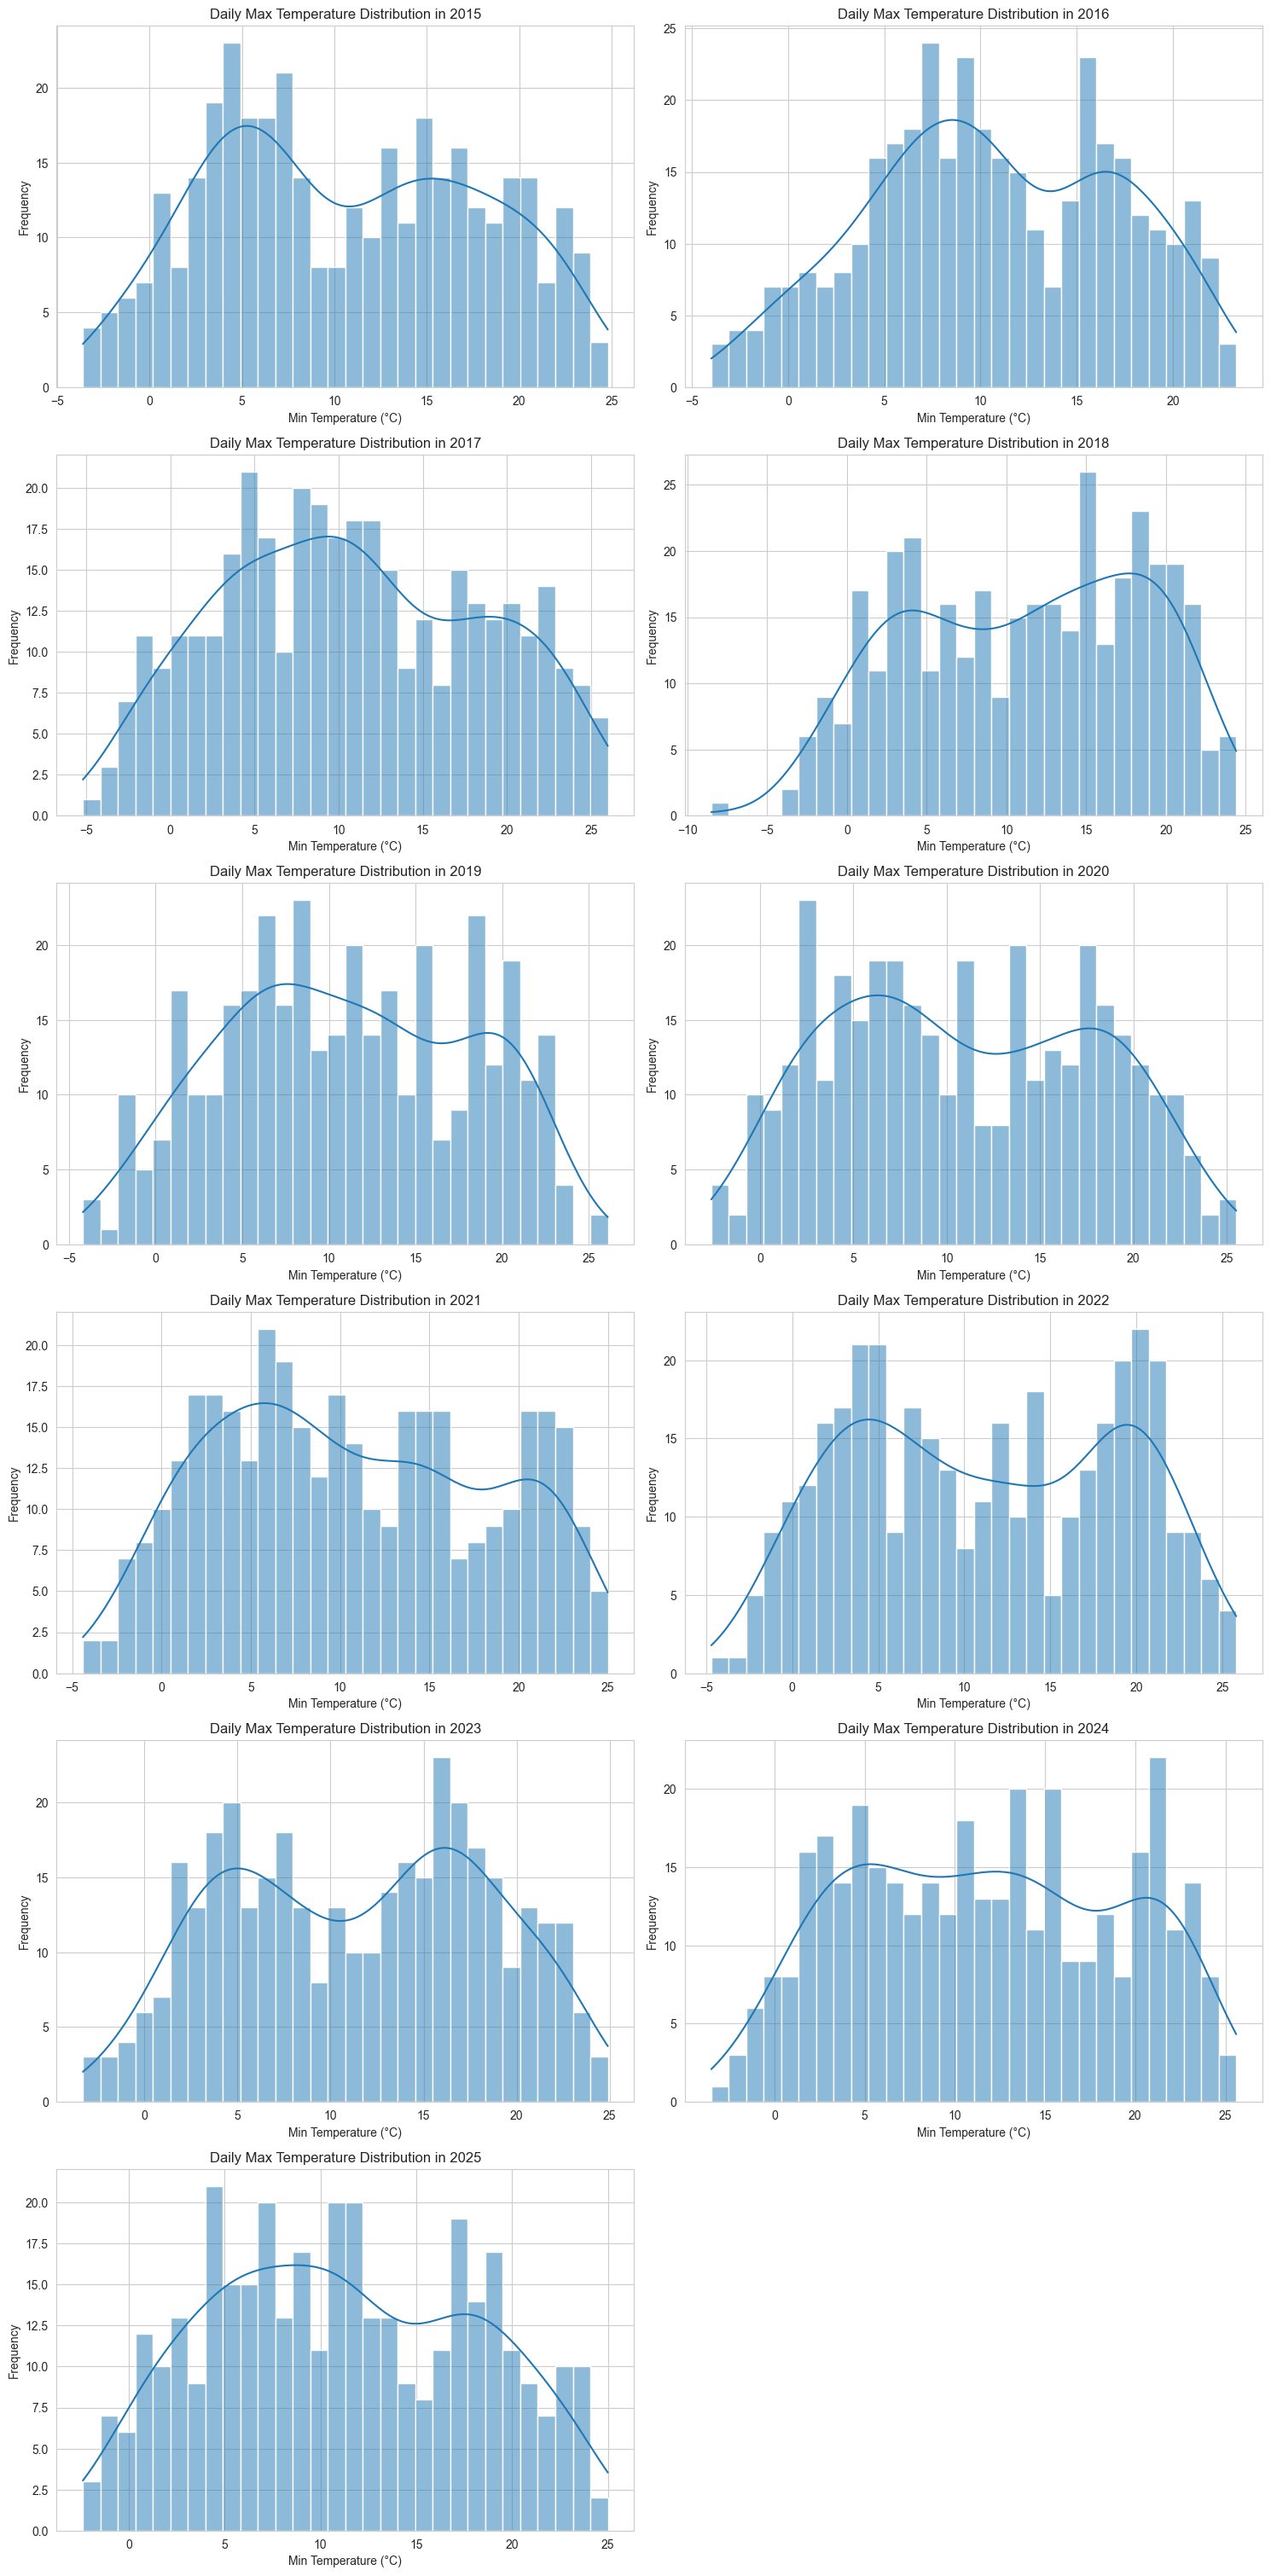

In [17]:
plt.figure(figsize=(15, 5 * len(years)))

for i, year in enumerate(years):
    plt.subplot(len(years), 2, i + 1)
    sns.histplot(df[df['year'] == year]['temp_min (°C)'], kde=True, bins=30)
    plt.title(f'Daily Max Temperature Distribution in {year}')
    plt.xlabel('Min Temperature (°C)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Temperature by Season
**Seasonal analysis with boxplot and statistics**

In [18]:
df_monthly_avg = df.groupby(['year', 'month'])[['temp_max (°C)', 'temp_min (°C)']].mean().reset_index()
display(df_monthly_avg.head())

,year,month,temp_max (°C),temp_min (°C)
0,2015,1,9.493548,2.487097
1,2015,2,8.946429,1.957143
2,2015,3,12.841935,4.622581
3,2015,4,17.423333,7.663333
4,2015,5,21.932258,13.425806


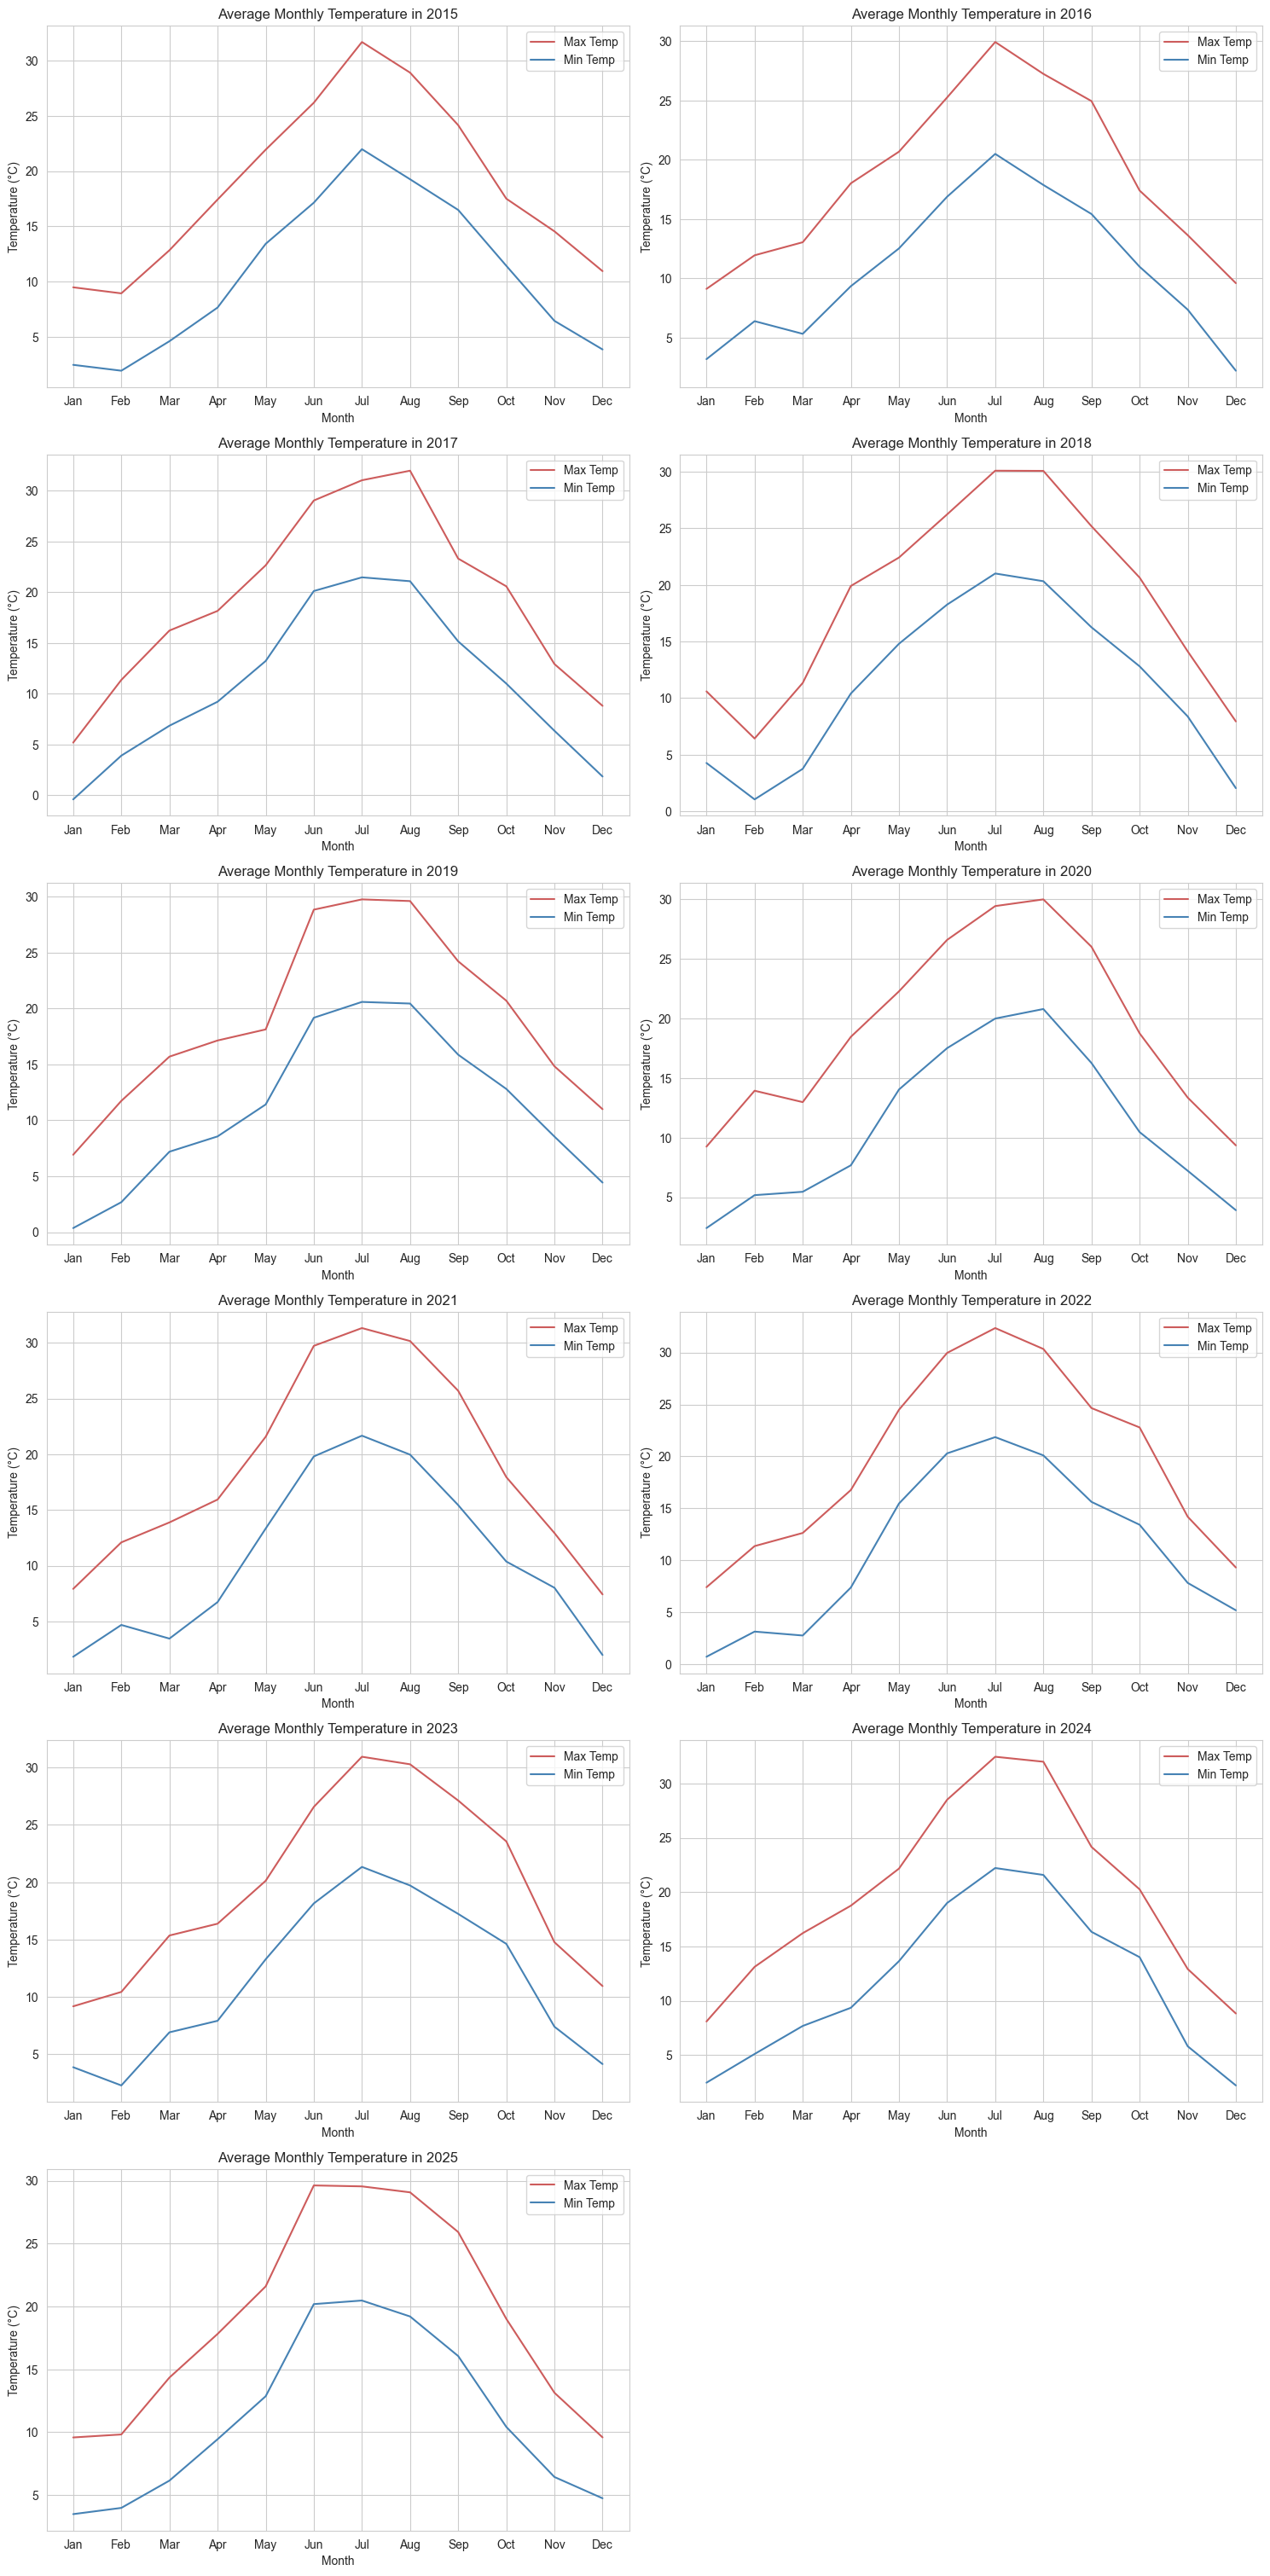

In [19]:
plt.figure(figsize=(15, 5 * len(years)))

for i, year in enumerate(years):
    plt.subplot(len(years), 2, i + 1)
    sns.lineplot(data=df_monthly_avg[df_monthly_avg['year'] == year], x='month', y='temp_max (°C)', color='indianred', label='Max Temp')
    sns.lineplot(data=df_monthly_avg[df_monthly_avg['year'] == year], x='month', y='temp_min (°C)', color='steelblue', label='Min Temp')
    plt.title(f'Average Monthly Temperature in {year}')
    plt.xlabel('Month')
    plt.ylabel('Temperature (°C)')
    plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

C:\Users\elzem\AppData\Local\Temp\ipykernel_15656\259213109.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y='temp_max (°C)',


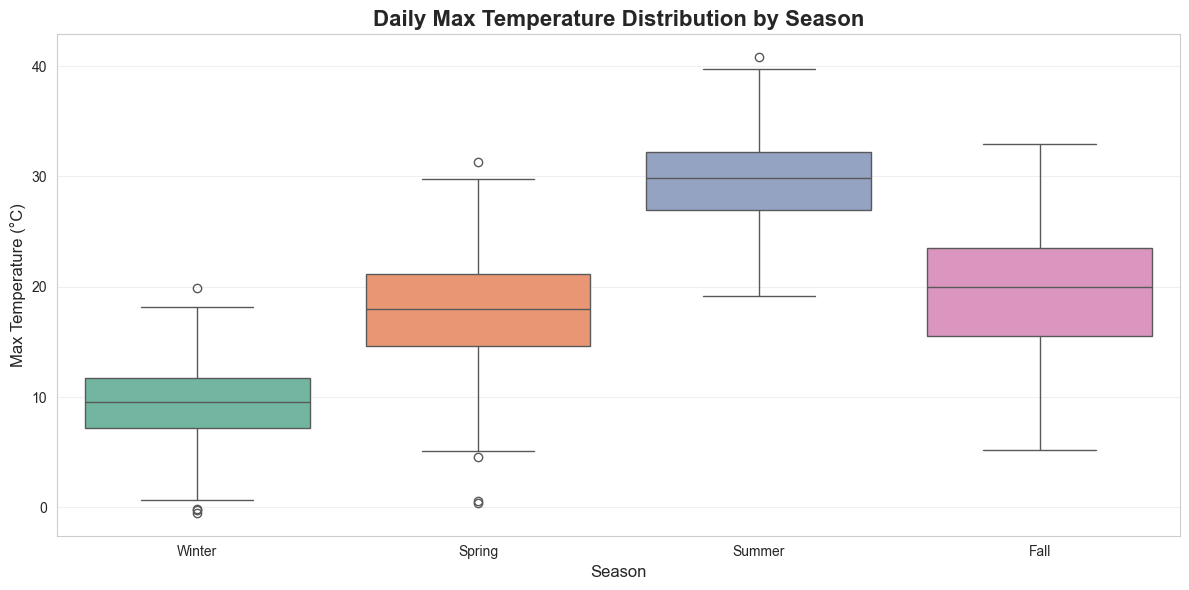

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='season', y='temp_max (°C)', 
            order=['Winter', 'Spring', 'Summer', 'Fall'],
            palette='Set2')
plt.title('Daily Max Temperature Distribution by Season', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Max Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

We can observe there are some outliers.

In [21]:
print('\nDaily Max Temperature Statistics by Season:')
print(df.groupby('season')['temp_max (°C)'].describe())

print('\nDaily Min Temperature Statistics by Season:')
print(df.groupby('season')['temp_min (°C)'].describe())


Daily Max Temperature Statistics by Season:
         count       mean       std   min   25%   50%   75%   max
season                                                           
Fall    1001.0  19.573526  5.713199   5.2  15.5  20.0  23.5  32.9
Spring  1012.0  17.796146  4.772680   0.4  14.6  18.0  21.2  31.3
Summer  1012.0  29.547628  3.597453  19.2  27.0  29.9  32.2  40.8
Winter   993.0   9.588721  3.261471  -0.5   7.2   9.6  11.7  19.9

Daily Min Temperature Statistics by Season:
         count       mean       std   min   25%   50%   75%   max
season                                                           
Fall    1001.0  11.768332  4.655956  -1.9   8.4  12.0  15.3  23.5
Spring  1012.0   9.152964  4.540472  -3.4   5.8   9.4  12.6  20.4
Summer  1012.0  20.007411  2.612985  11.1  18.2  20.2  22.0  26.1
Winter   993.0   3.066667  3.256969  -8.5   0.9   3.0   5.2  14.0


### Correlation Matrix
**IMPORTANT! Analyzing feature correlations to decide which features to keep/remove**

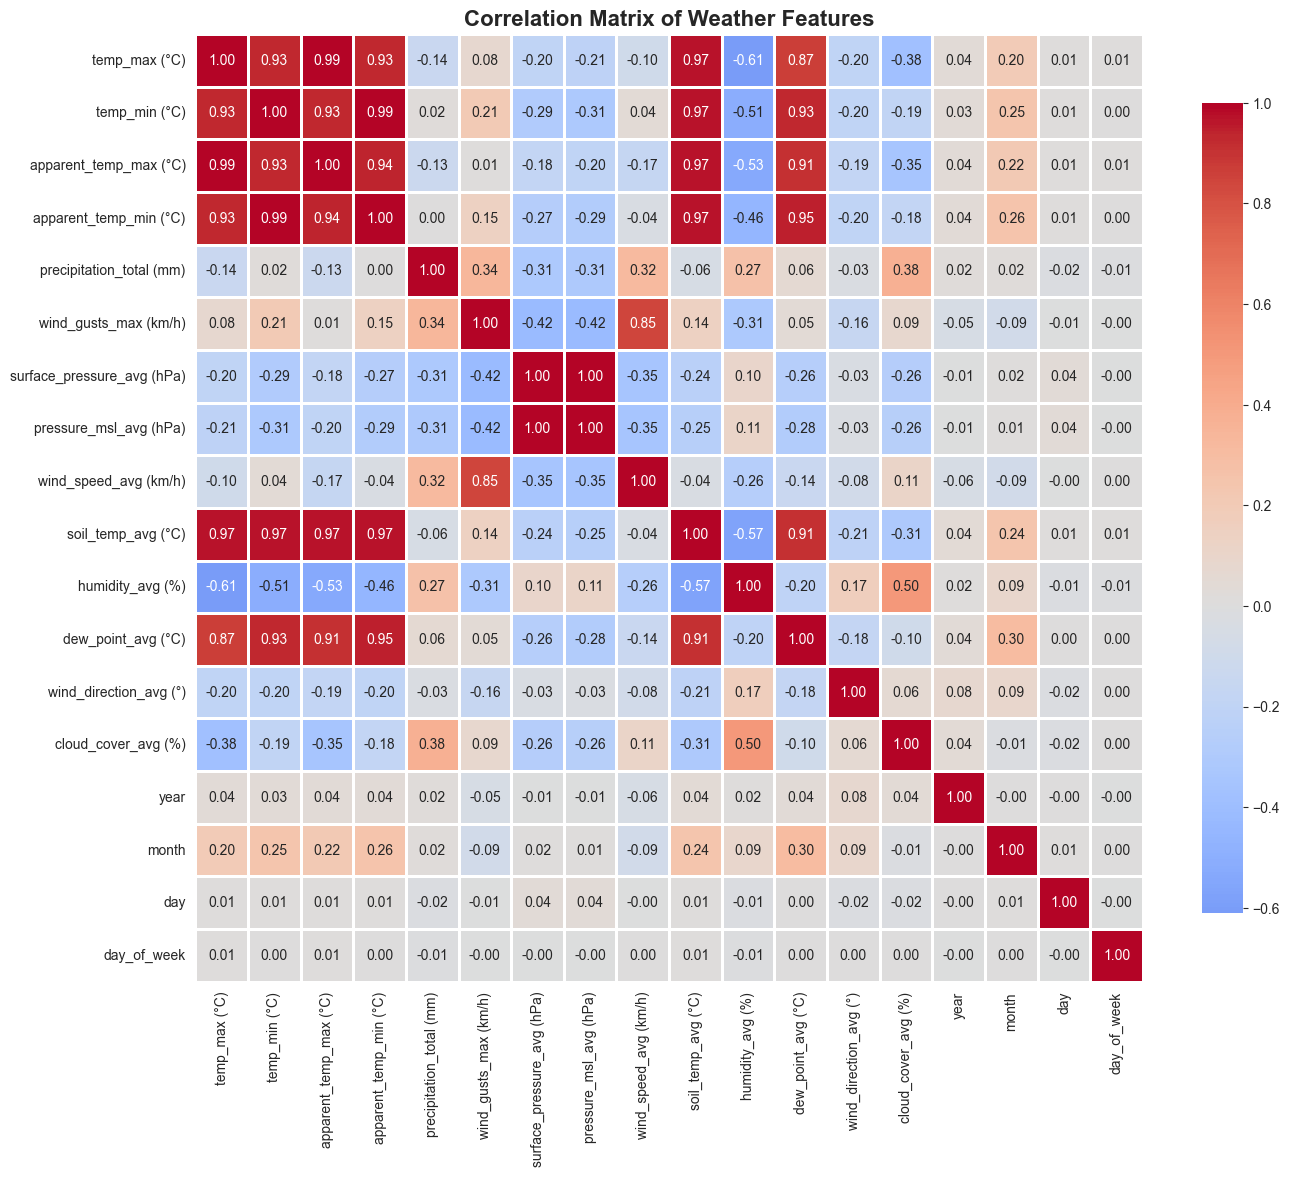

In [22]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()

# Visualize correlation matrix
plt.figure(figsize=(14, 12))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Weather Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# Show correlation with temperature specifically
print('CORRELATION WITH MAX TEMPERATURE (Target Variable)')
temp_corr = correlation['temp_max (°C)'].sort_values(ascending=False)
print(temp_corr)

CORRELATION WITH MAX TEMPERATURE (Target Variable)
temp_max (°C)                 1.000000
apparent_temp_max (°C)        0.991384
soil_temp_avg (°C)            0.972392
apparent_temp_min (°C)        0.928479
temp_min (°C)                 0.926654
dew_point_avg (°C)            0.871184
month                         0.199000
wind_gusts_max (km/h)         0.078407
year                          0.035468
day_of_week                   0.011040
day                           0.006863
wind_speed_avg (km/h)        -0.096553
precipitation_total (mm)     -0.143387
surface_pressure_avg (hPa)   -0.196815
wind_direction_avg (°)       -0.197436
pressure_msl_avg (hPa)       -0.214943
cloud_cover_avg (%)          -0.379700
humidity_avg (%)             -0.610229
Name: temp_max (°C), dtype: float64


In [24]:
print('HIGHLY CORRELATED FEATURE PAIRS (>0.9)')
high_corr_pairs = []
for i in range(len(correlation.columns)):
    for j in range(i+1, len(correlation.columns)):
        if abs(correlation.iloc[i, j]) > 0.9:
            high_corr_pairs.append((correlation.columns[i], correlation.columns[j], correlation.iloc[i, j]))

for pair in high_corr_pairs:
    print(f"{pair[0]} <-> {pair[1]}: {pair[2]:.3f}")

HIGHLY CORRELATED FEATURE PAIRS (>0.9)
temp_max (°C) <-> temp_min (°C): 0.927
temp_max (°C) <-> apparent_temp_max (°C): 0.991
temp_max (°C) <-> apparent_temp_min (°C): 0.928
temp_max (°C) <-> soil_temp_avg (°C): 0.972
temp_min (°C) <-> apparent_temp_max (°C): 0.929
temp_min (°C) <-> apparent_temp_min (°C): 0.993
temp_min (°C) <-> soil_temp_avg (°C): 0.973
temp_min (°C) <-> dew_point_avg (°C): 0.925
apparent_temp_max (°C) <-> apparent_temp_min (°C): 0.939
apparent_temp_max (°C) <-> soil_temp_avg (°C): 0.970
apparent_temp_max (°C) <-> dew_point_avg (°C): 0.907
apparent_temp_min (°C) <-> soil_temp_avg (°C): 0.972
apparent_temp_min (°C) <-> dew_point_avg (°C): 0.949
surface_pressure_avg (hPa) <-> pressure_msl_avg (hPa): 1.000
soil_temp_avg (°C) <-> dew_point_avg (°C): 0.907


### Feature Selection Decision
**Documenting which features to keep/remove based on correlation analysis**

**Feature Selection for Daily Aggregated Data:**

Features to REMOVE:
1. 'apparent_temp_max/min' - Derived from temperature (multicollinearity)
2. 'dew_point_avg' - Highly correlated with temperature
3. 'soil_temp_avg' - Very similar to air temperature
4. 'surface_pressure_avg' - Keep only pressure_msl (they're almost identical)
5. 'year', 'day' - Not useful for prediction (too specific)
6. 'hour' - No longer exists in daily aggregated data

Features to KEEP:
1. precipitation_total (mm) - Daily total rainfall
2. pressure_msl_avg (hPa) - Daily average sea-level pressure
3. wind_speed_avg (km/h) - Daily average wind speed
4. wind_direction_avg (°) - Daily average wind direction
5. wind_gusts_max (km/h) - Daily maximum wind gusts
6. humidity_avg (%) - Daily average relative humidity
7. cloud_cover_avg (%) - Daily average cloud cover
8. month - Seasonal patterns
9. day_of_week - Weekly patterns

In [25]:
# Define features to keep for modeling (updated for daily aggregated data)
features_to_keep = [
    'precipitation_total (mm)',
    'pressure_msl_avg (hPa)',
    'wind_speed_avg (km/h)',
    'wind_direction_avg (°)',
    'wind_gusts_max (km/h)',
    'humidity_avg (%)',
    'cloud_cover_avg (%)',
    'month',
    'day_of_week'
]

---
## Data Preparation
### Train-Test Split (Chronological)
**IMPORTANT! Splitting data chronologically (NOT random) for time series**

In [26]:
# Define features and targets (multi-output: both max and min temperature)
X = df[features_to_keep]
y = df[['temp_max (°C)', 'temp_min (°C)']]

# Chronological split: 2015-2022 for training, 2023-2025 for testing (72% for training)
train_mask = df['year'] < 2023
test_mask = df['year'] >= 2023

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f'Training set: {X_train.shape[0]} samples 2015-2022')
print(f'Testing set: {X_test.shape[0]} samples 2023-2025')
print(f'Number of features: {X_train.shape[1]}')
print(f'Target variables: temp_max (°C), temp_min (°C)')

Training set: 2922 samples 2015-2022
Testing set: 1096 samples 2023-2025
Number of features: 9
Target variables: temp_max (°C), temp_min (°C)


### Feature Scaling
**Scaling features using StandardScaler (fit on training data only!)**
It is the same method as we learnt in the class: (X - X.mean()) / X.std()

In [27]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
## Model Training
### Linear Regression (Baseline)
**Training Linear Regression as baseline model**

In [28]:
# Train Linear Regression (natively supports multi-output)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

# Evaluate for both outputs
print('LINEAR REGRESSION RESULTS (Multi-Output)')
for i, target_name in enumerate(['temp_max (°C)', 'temp_min (°C)']):
    train_rmse = np.sqrt(mean_squared_error(y_train.iloc[:, i], y_pred_lr_train[:, i]))
    test_rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_lr_test[:, i]))
    train_mae = mean_absolute_error(y_train.iloc[:, i], y_pred_lr_train[:, i])
    test_mae = mean_absolute_error(y_test.iloc[:, i], y_pred_lr_test[:, i])
    train_r2 = r2_score(y_train.iloc[:, i], y_pred_lr_train[:, i])
    test_r2 = r2_score(y_test.iloc[:, i], y_pred_lr_test[:, i])
    print(f'\n{target_name}:')
    print(f'  Training RMSE: {train_rmse:.3f}°C | Testing RMSE: {test_rmse:.3f}°C')
    print(f'  Training MAE: {train_mae:.3f}°C | Testing MAE: {test_mae:.3f}°C')
    print(f'  Training R²: {train_r2:.3f} | Testing R²: {test_r2:.3f}')

# Store average metrics for comparison
lr_train_rmse = np.mean([np.sqrt(mean_squared_error(y_train.iloc[:, i], y_pred_lr_train[:, i])) for i in range(2)])
lr_test_rmse = np.mean([np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_lr_test[:, i])) for i in range(2)])
lr_train_mae = np.mean([mean_absolute_error(y_train.iloc[:, i], y_pred_lr_train[:, i]) for i in range(2)])
lr_test_mae = np.mean([mean_absolute_error(y_test.iloc[:, i], y_pred_lr_test[:, i]) for i in range(2)])
lr_train_r2 = np.mean([r2_score(y_train.iloc[:, i], y_pred_lr_train[:, i]) for i in range(2)])
lr_test_r2 = np.mean([r2_score(y_test.iloc[:, i], y_pred_lr_test[:, i]) for i in range(2)])
print(f'\nAverage Metrics:')
print(f'  Avg Training RMSE: {lr_train_rmse:.3f}°C | Avg Testing RMSE: {lr_test_rmse:.3f}°C')
print(f'  Avg Training R²: {lr_train_r2:.3f} | Avg Testing R²: {lr_test_r2:.3f}')

LINEAR REGRESSION RESULTS (Multi-Output)

temp_max (°C):
  Training RMSE: 5.294°C | Testing RMSE: 5.269°C
  Training MAE: 4.182°C | Testing MAE: 4.303°C
  Training R²: 0.601 | Testing R²: 0.599

temp_min (°C):
  Training RMSE: 5.115°C | Testing RMSE: 5.037°C
  Training MAE: 4.091°C | Testing MAE: 4.133°C
  Training R²: 0.503 | Testing R²: 0.490

Average Metrics:
  Avg Training RMSE: 5.204°C | Avg Testing RMSE: 5.153°C
  Avg Training R²: 0.552 | Avg Testing R²: 0.545


### Random Forest Regressor
**Training Random Forest with hyperparameter tuning using GridSearchCV**

In [29]:
# Hyperparameter tuning for Random Forest (natively supports multi-output)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
rf_grid_search.fit(X_train_scaled, y_train)

print('RANDOM FOREST HYPERPARAMETER TUNING')
print(f'Best parameters: {rf_grid_search.best_params_}')
print(f'Best CV score (neg MSE): {rf_grid_search.best_score_:.4f}')

# Use best model
rf_model = rf_grid_search.best_estimator_

# Predictions
y_pred_rf_train = rf_model.predict(X_train_scaled)
y_pred_rf_test = rf_model.predict(X_test_scaled)

# Evaluate for both outputs
print('\nRANDOM FOREST RESULTS (Multi-Output, with best hyperparameters)')
for i, target_name in enumerate(['temp_max (°C)', 'temp_min (°C)']):
    train_rmse = np.sqrt(mean_squared_error(y_train.iloc[:, i], y_pred_rf_train[:, i]))
    test_rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_rf_test[:, i]))
    train_mae = mean_absolute_error(y_train.iloc[:, i], y_pred_rf_train[:, i])
    test_mae = mean_absolute_error(y_test.iloc[:, i], y_pred_rf_test[:, i])
    train_r2 = r2_score(y_train.iloc[:, i], y_pred_rf_train[:, i])
    test_r2 = r2_score(y_test.iloc[:, i], y_pred_rf_test[:, i])
    print(f'\n{target_name}:')
    print(f'  Training RMSE: {train_rmse:.3f}°C | Testing RMSE: {test_rmse:.3f}°C')
    print(f'  Training MAE: {train_mae:.3f}°C | Testing MAE: {test_mae:.3f}°C')
    print(f'  Training R²: {train_r2:.3f} | Testing R²: {test_r2:.3f}')

# Store average metrics for comparison
rf_train_rmse = np.mean([np.sqrt(mean_squared_error(y_train.iloc[:, i], y_pred_rf_train[:, i])) for i in range(2)])
rf_test_rmse = np.mean([np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_rf_test[:, i])) for i in range(2)])
rf_train_mae = np.mean([mean_absolute_error(y_train.iloc[:, i], y_pred_rf_train[:, i]) for i in range(2)])
rf_test_mae = np.mean([mean_absolute_error(y_test.iloc[:, i], y_pred_rf_test[:, i]) for i in range(2)])
rf_train_r2 = np.mean([r2_score(y_train.iloc[:, i], y_pred_rf_train[:, i]) for i in range(2)])
rf_test_r2 = np.mean([r2_score(y_test.iloc[:, i], y_pred_rf_test[:, i]) for i in range(2)])
print(f'\nAverage Metrics:')
print(f'  Avg Training RMSE: {rf_train_rmse:.3f}°C | Avg Testing RMSE: {rf_test_rmse:.3f}°C')
print(f'  Avg Training R²: {rf_train_r2:.3f} | Avg Testing R²: {rf_test_r2:.3f}')

RANDOM FOREST HYPERPARAMETER TUNING
Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score (neg MSE): -8.4437

RANDOM FOREST RESULTS (Multi-Output, with best hyperparameters)

temp_max (°C):
  Training RMSE: 1.729°C | Testing RMSE: 2.916°C
  Training MAE: 1.375°C | Testing MAE: 2.337°C
  Training R²: 0.957 | Testing R²: 0.877

temp_min (°C):
  Training RMSE: 1.726°C | Testing RMSE: 2.714°C
  Training MAE: 1.377°C | Testing MAE: 2.184°C
  Training R²: 0.943 | Testing R²: 0.852

Average Metrics:
  Avg Training RMSE: 1.727°C | Avg Testing RMSE: 2.815°C
  Avg Training R²: 0.950 | Avg Testing R²: 0.865


### Support Vector Regression (SVR)
**Training SVR with hyperparameter tuning using GridSearchCV**

In [30]:
# Hyperparameter tuning for SVR with MultiOutputRegressor wrapper
# SVR doesn't natively support multi-output, so we wrap it
svr_param_grid = {
    'estimator__C': [10, 100],
    'estimator__gamma': ['scale', 0.1, 0.01],
    'estimator__epsilon': [0.1, 0.5]
}

svr_grid_search = GridSearchCV(
    MultiOutputRegressor(SVR(kernel='rbf')),
    svr_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
svr_grid_search.fit(X_train_scaled, y_train)

print('SVR HYPERPARAMETER TUNING (Multi-Output)')
print(f'Best parameters: {svr_grid_search.best_params_}')
print(f'Best CV score (neg MSE): {svr_grid_search.best_score_:.4f}')

# Use best model
svr_model = svr_grid_search.best_estimator_

# Predictions
y_pred_svr_train = svr_model.predict(X_train_scaled)
y_pred_svr_test = svr_model.predict(X_test_scaled)

# Evaluate for both outputs
print('\nSVR RESULTS (Multi-Output, with best hyperparameters)')
for i, target_name in enumerate(['temp_max (°C)', 'temp_min (°C)']):
    train_rmse = np.sqrt(mean_squared_error(y_train.iloc[:, i], y_pred_svr_train[:, i]))
    test_rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_svr_test[:, i]))
    train_mae = mean_absolute_error(y_train.iloc[:, i], y_pred_svr_train[:, i])
    test_mae = mean_absolute_error(y_test.iloc[:, i], y_pred_svr_test[:, i])
    train_r2 = r2_score(y_train.iloc[:, i], y_pred_svr_train[:, i])
    test_r2 = r2_score(y_test.iloc[:, i], y_pred_svr_test[:, i])
    print(f'\n{target_name}:')
    print(f'  Training RMSE: {train_rmse:.3f}°C | Testing RMSE: {test_rmse:.3f}°C')
    print(f'  Training MAE: {train_mae:.3f}°C | Testing MAE: {test_mae:.3f}°C')
    print(f'  Training R²: {train_r2:.3f} | Testing R²: {test_r2:.3f}')

# Store average metrics for comparison
svr_train_rmse = np.mean([np.sqrt(mean_squared_error(y_train.iloc[:, i], y_pred_svr_train[:, i])) for i in range(2)])
svr_test_rmse = np.mean([np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_svr_test[:, i])) for i in range(2)])
svr_train_mae = np.mean([mean_absolute_error(y_train.iloc[:, i], y_pred_svr_train[:, i]) for i in range(2)])
svr_test_mae = np.mean([mean_absolute_error(y_test.iloc[:, i], y_pred_svr_test[:, i]) for i in range(2)])
svr_train_r2 = np.mean([r2_score(y_train.iloc[:, i], y_pred_svr_train[:, i]) for i in range(2)])
svr_test_r2 = np.mean([r2_score(y_test.iloc[:, i], y_pred_svr_test[:, i]) for i in range(2)])
print(f'\nAverage Metrics:')
print(f'  Avg Training RMSE: {svr_train_rmse:.3f}°C | Avg Testing RMSE: {svr_test_rmse:.3f}°C')
print(f'  Avg Training R²: {svr_train_r2:.3f} | Avg Testing R²: {svr_test_r2:.3f}')

SVR HYPERPARAMETER TUNING (Multi-Output)
Best parameters: {'estimator__C': 10, 'estimator__epsilon': 0.5, 'estimator__gamma': 'scale'}
Best CV score (neg MSE): -10.0443

SVR RESULTS (Multi-Output, with best hyperparameters)

temp_max (°C):
  Training RMSE: 2.542°C | Testing RMSE: 3.080°C
  Training MAE: 1.907°C | Testing MAE: 2.450°C
  Training R²: 0.908 | Testing R²: 0.863

temp_min (°C):
  Training RMSE: 2.615°C | Testing RMSE: 2.956°C
  Training MAE: 1.938°C | Testing MAE: 2.367°C
  Training R²: 0.870 | Testing R²: 0.824

Average Metrics:
  Avg Training RMSE: 2.579°C | Avg Testing RMSE: 3.018°C
  Avg Training R²: 0.889 | Avg Testing R²: 0.844


### MLP Regressor (Neural Network)
**Training MLP with hyperparameter tuning using GridSearchCV**

In [31]:
# Hyperparameter tuning for MLP (natively supports multi-output)
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001]
}

mlp_grid_search = GridSearchCV(
    MLPRegressor(max_iter=500, random_state=42),
    mlp_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
mlp_grid_search.fit(X_train_scaled, y_train)

print('MLP HYPERPARAMETER TUNING')
print(f'Best parameters: {mlp_grid_search.best_params_}')
print(f'Best CV score (neg MSE): {mlp_grid_search.best_score_:.4f}')

# Use best model
mlp_model = mlp_grid_search.best_estimator_

# Predictions
y_pred_mlp_train = mlp_model.predict(X_train_scaled)
y_pred_mlp_test = mlp_model.predict(X_test_scaled)

# Evaluate for both outputs
print('\nMLP RESULTS (Multi-Output, with best hyperparameters)')
for i, target_name in enumerate(['temp_max (°C)', 'temp_min (°C)']):
    train_rmse = np.sqrt(mean_squared_error(y_train.iloc[:, i], y_pred_mlp_train[:, i]))
    test_rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_mlp_test[:, i]))
    train_mae = mean_absolute_error(y_train.iloc[:, i], y_pred_mlp_train[:, i])
    test_mae = mean_absolute_error(y_test.iloc[:, i], y_pred_mlp_test[:, i])
    train_r2 = r2_score(y_train.iloc[:, i], y_pred_mlp_train[:, i])
    test_r2 = r2_score(y_test.iloc[:, i], y_pred_mlp_test[:, i])
    print(f'\n{target_name}:')
    print(f'  Training RMSE: {train_rmse:.3f}°C | Testing RMSE: {test_rmse:.3f}°C')
    print(f'  Training MAE: {train_mae:.3f}°C | Testing MAE: {test_mae:.3f}°C')
    print(f'  Training R²: {train_r2:.3f} | Testing R²: {test_r2:.3f}')

# Store average metrics for comparison
mlp_train_rmse = np.mean([np.sqrt(mean_squared_error(y_train.iloc[:, i], y_pred_mlp_train[:, i])) for i in range(2)])
mlp_test_rmse = np.mean([np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_mlp_test[:, i])) for i in range(2)])
mlp_train_mae = np.mean([mean_absolute_error(y_train.iloc[:, i], y_pred_mlp_train[:, i]) for i in range(2)])
mlp_test_mae = np.mean([mean_absolute_error(y_test.iloc[:, i], y_pred_mlp_test[:, i]) for i in range(2)])
mlp_train_r2 = np.mean([r2_score(y_train.iloc[:, i], y_pred_mlp_train[:, i]) for i in range(2)])
mlp_test_r2 = np.mean([r2_score(y_test.iloc[:, i], y_pred_mlp_test[:, i]) for i in range(2)])
print(f'\nAverage Metrics:')
print(f'  Avg Training RMSE: {mlp_train_rmse:.3f}°C | Avg Testing RMSE: {mlp_test_rmse:.3f}°C')
print(f'  Avg Training R²: {mlp_train_r2:.3f} | Avg Testing R²: {mlp_test_r2:.3f}')

MLP HYPERPARAMETER TUNING
Best parameters: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (50,)}
Best CV score (neg MSE): -7.9847

MLP RESULTS (Multi-Output, with best hyperparameters)

temp_max (°C):
  Training RMSE: 2.578°C | Testing RMSE: 2.835°C
  Training MAE: 2.060°C | Testing MAE: 2.287°C
  Training R²: 0.905 | Testing R²: 0.884

temp_min (°C):
  Training RMSE: 2.563°C | Testing RMSE: 2.633°C
  Training MAE: 2.044°C | Testing MAE: 2.142°C
  Training R²: 0.875 | Testing R²: 0.861

Average Metrics:
  Avg Training RMSE: 2.570°C | Avg Testing RMSE: 2.734°C
  Avg Training R²: 0.890 | Avg Testing R²: 0.872


C:\Users\elzem\Documents\DMML-Weather-Prediction\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


---
## Model Evaluation & Comparison
### Model Comparison Table
**Comparing all models side-by-side**

In [32]:
# Create comparison dataframe with average metrics (avg across both outputs)
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'SVR', 'MLP (Neural Network)'],
    'Avg Train RMSE': [lr_train_rmse, rf_train_rmse, svr_train_rmse, mlp_train_rmse],
    'Avg Test RMSE': [lr_test_rmse, rf_test_rmse, svr_test_rmse, mlp_test_rmse],
    'Avg Train MAE': [lr_train_mae, rf_train_mae, svr_train_mae, mlp_train_mae],
    'Avg Test MAE': [lr_test_mae, rf_test_mae, svr_test_mae, mlp_test_mae],
    'Avg Train R²': [lr_train_r2, rf_train_r2, svr_train_r2, mlp_train_r2],
    'Avg Test R²': [lr_test_r2, rf_test_r2, svr_test_r2, mlp_test_r2]
})

print('MODEL COMPARISON (Multi-Output: Average Metrics)')
print(results.to_string(index=False))
print(f'\nBest Model (by Avg Test RMSE): {results.loc[results["Avg Test RMSE"].idxmin(), "Model"]}')
print(f'Best Avg Test RMSE: {results["Avg Test RMSE"].min():.3f}°C')

MODEL COMPARISON (Multi-Output: Average Metrics)
               Model  Avg Train RMSE  Avg Test RMSE  Avg Train MAE  Avg Test MAE  Avg Train R²  Avg Test R²
   Linear Regression        5.204455       5.152887       4.136597      4.218036      0.552151     0.544729
       Random Forest        1.727498       2.814836       1.376131      2.260411      0.950439     0.864635
                 SVR        2.578700       3.018426       1.922380      2.408769      0.889070     0.843692
MLP (Neural Network)        2.570212       2.734135       2.052108      2.214590      0.890358     0.872324

Best Model (by Avg Test RMSE): MLP (Neural Network)
Best Avg Test RMSE: 2.734°C


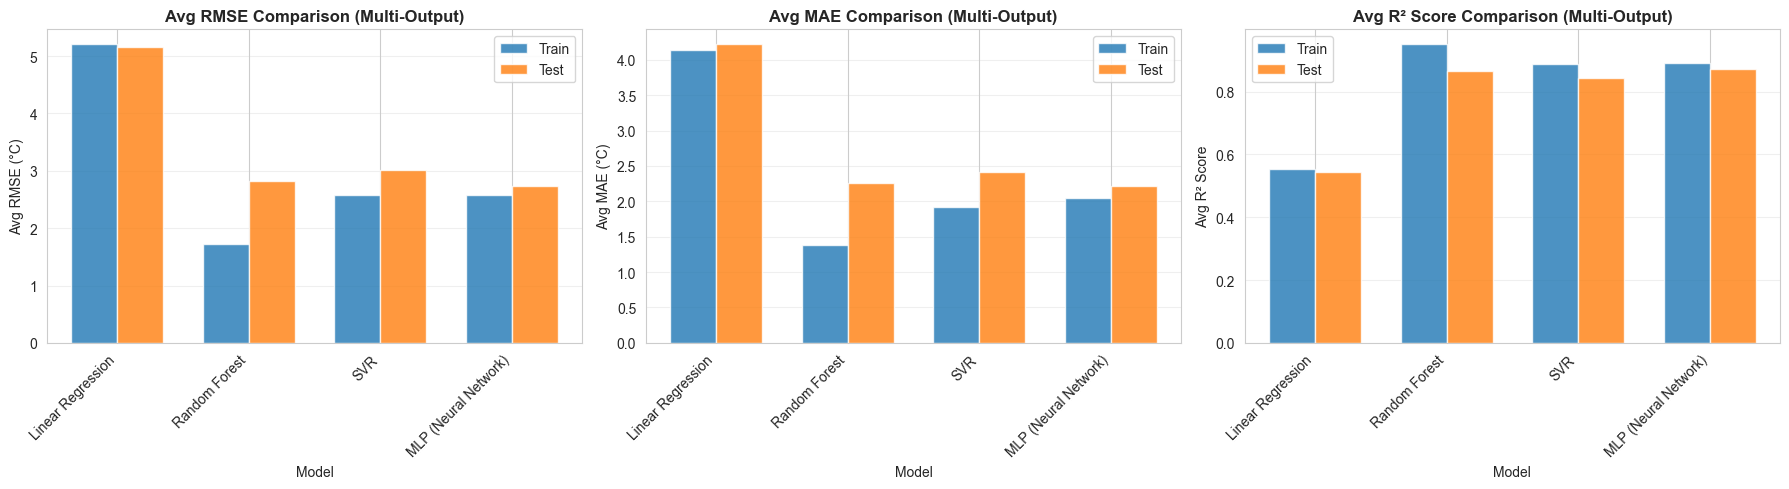

In [33]:
# Visualize comparison (using average metrics for multi-output)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE comparison
x = np.arange(len(results))
width = 0.35
axes[0].bar(x - width/2, results['Avg Train RMSE'], width, label='Train', alpha=0.8)
axes[0].bar(x + width/2, results['Avg Test RMSE'], width, label='Test', alpha=0.8)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Avg RMSE (°C)')
axes[0].set_title('Avg RMSE Comparison (Multi-Output)', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# MAE comparison
axes[1].bar(x - width/2, results['Avg Train MAE'], width, label='Train', alpha=0.8)
axes[1].bar(x + width/2, results['Avg Test MAE'], width, label='Test', alpha=0.8)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Avg MAE (°C)')
axes[1].set_title('Avg MAE Comparison (Multi-Output)', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# R² comparison
axes[2].bar(x - width/2, results['Avg Train R²'], width, label='Train', alpha=0.8)
axes[2].bar(x + width/2, results['Avg Test R²'], width, label='Test', alpha=0.8)
axes[2].set_xlabel('Model')
axes[2].set_ylabel('Avg R² Score')
axes[2].set_title('Avg R² Score Comparison (Multi-Output)', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(results['Model'], rotation=45, ha='right')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Feature Importance (Random Forest)
**Analyzing which features are most important for prediction**

In [34]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': features_to_keep,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('FEATURE IMPORTANCE (Random Forest)')
print(feature_importance.to_string(index=False))

FEATURE IMPORTANCE (Random Forest)
                 Feature  Importance
                   month    0.869990
        humidity_avg (%)    0.027916
  wind_direction_avg (°)    0.021616
precipitation_total (mm)    0.017493
  pressure_msl_avg (hPa)    0.016664
     cloud_cover_avg (%)    0.015095
   wind_speed_avg (km/h)    0.014415
   wind_gusts_max (km/h)    0.012153
             day_of_week    0.004657


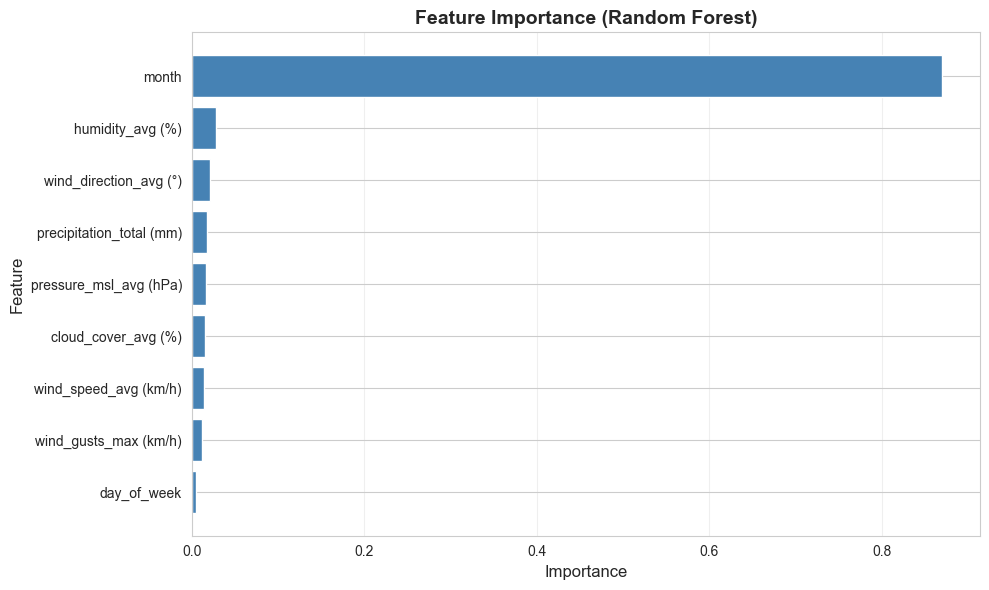

In [35]:
# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Actual vs Predicted (Best Model)
**Visualizing predictions vs actual values**

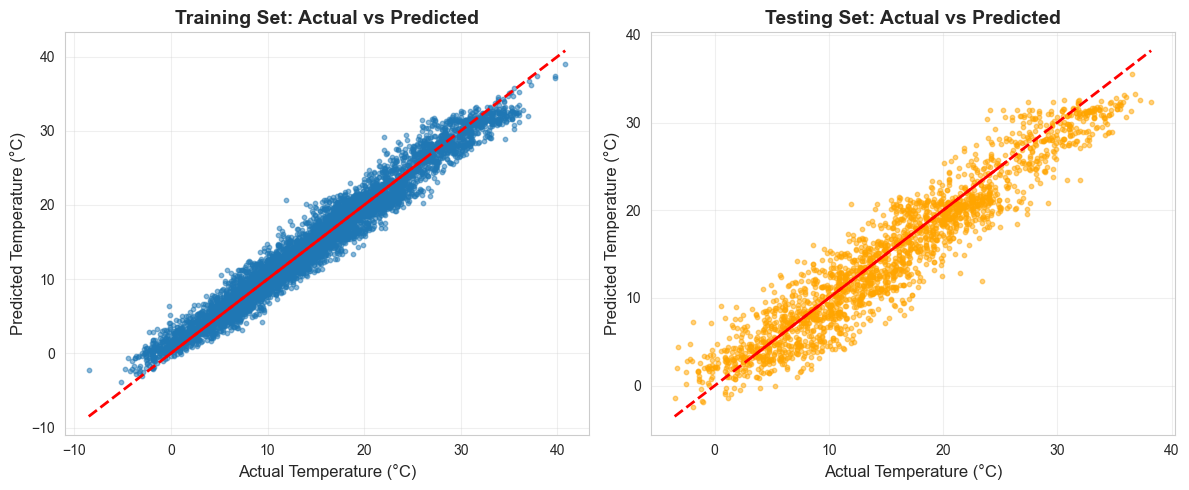

In [36]:
# Use Random Forest predictions (likely the best model)
plt.figure(figsize=(12, 5))

# Training set
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_rf_train, alpha=0.5, s=10)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°C)', fontsize=12)
plt.ylabel('Predicted Temperature (°C)', fontsize=12)
plt.title('Training Set: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Testing set
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf_test, alpha=0.5, s=10, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°C)', fontsize=12)
plt.ylabel('Predicted Temperature (°C)', fontsize=12)
plt.title('Testing Set: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## TIME HORIZON FORECASTING
### Create Lagged Target Variables
**Creating 3-day, 5-day, and 7-day ahead temperature targets**

In [37]:
# Create a copy for forecasting
df_forecast = df.copy()

# Sort by date to ensure correct order
df_forecast = df_forecast.sort_values('date').reset_index(drop=True)

# Data is now daily (1 observation per day), so:
# 3 days ahead = shift(-3)
# 5 days ahead = shift(-5)
# 7 days ahead = shift(-7)

# Create target variables for different horizons (multi-output: both max and min temperature)
# Max temperature targets
df_forecast['temp_max_3day_ahead'] = df_forecast['temp_max (°C)'].shift(-3)  # 3 days
df_forecast['temp_max_5day_ahead'] = df_forecast['temp_max (°C)'].shift(-5)  # 5 days
df_forecast['temp_max_7day_ahead'] = df_forecast['temp_max (°C)'].shift(-7)  # 7 days

# Min temperature targets
df_forecast['temp_min_3day_ahead'] = df_forecast['temp_min (°C)'].shift(-3)  # 3 days
df_forecast['temp_min_5day_ahead'] = df_forecast['temp_min (°C)'].shift(-5)  # 5 days
df_forecast['temp_min_7day_ahead'] = df_forecast['temp_min (°C)'].shift(-7)  # 7 days

# Remove rows with NaN (last 7 rows won't have 7-day ahead values)
df_forecast_clean = df_forecast.dropna()

print(f'\nOriginal dataset: {len(df)} rows')
print(f'Forecast dataset: {len(df_forecast_clean)} rows (removed last 7 rows with NaN)')
print('Target variables created for both temp_max and temp_min at 3, 5, and 7 days ahead')


Original dataset: 4018 rows
Forecast dataset: 4011 rows (removed last 7 rows with NaN)
Target variables created for both temp_max and temp_min at 3, 5, and 7 days ahead


### Train Models for Each Horizon
**Training separate models for 3-day, 5-day, and 7-day forecasts**

In [38]:
# Prepare data for forecasting
X_forecast = df_forecast_clean[features_to_keep]

# Chronological split (same as before)
train_mask_forecast = df_forecast_clean['year'] < 2023
test_mask_forecast = df_forecast_clean['year'] >= 2023

X_train_forecast = X_forecast[train_mask_forecast]
X_test_forecast = X_forecast[test_mask_forecast]

# Scale features
scaler_forecast = StandardScaler()
X_train_forecast_scaled = scaler_forecast.fit_transform(X_train_forecast)
X_test_forecast_scaled = scaler_forecast.transform(X_test_forecast)


print(f'Training samples: {X_train_forecast.shape[0]}')
print(f'Testing samples: {X_test_forecast.shape[0]}')
print(f'Features: {X_train_forecast.shape[1]}')

Training samples: 2922
Testing samples: 1089
Features: 9


In [39]:
# Dictionary to store results
results_by_horizon = {}

# Train models for each horizon (multi-output: max and min temperature)
horizons = [
    ('3-day', ['temp_max_3day_ahead', 'temp_min_3day_ahead'], 3),
    ('5-day', ['temp_max_5day_ahead', 'temp_min_5day_ahead'], 5),
    ('7-day', ['temp_max_7day_ahead', 'temp_min_7day_ahead'], 7)
]

# Define parameter grids for hyperparameter tuning
rf_param_grid_h = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None]
}

# SVR needs MultiOutputRegressor wrapper, so prefix params with estimator__
svr_param_grid_h = {
    'estimator__C': [10, 100],
    'estimator__gamma': ['scale', 0.1]
}

mlp_param_grid_h = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'alpha': [0.0001, 0.001]
}

for horizon_name, target_cols, days in horizons:
    print(f'TRAINING FOR {horizon_name.upper()} HORIZON ({days} days ahead) - Multi-Output')
    
    # Get multi-output target for this horizon
    y_train_h = df_forecast_clean.loc[train_mask_forecast, target_cols]
    y_test_h = df_forecast_clean.loc[test_mask_forecast, target_cols]
    
    # Train all 4 models
    models_h = {}
    
    # 1. Linear Regression (natively supports multi-output)
    lr_h = LinearRegression()
    lr_h.fit(X_train_forecast_scaled, y_train_h)
    models_h['Linear Regression'] = lr_h
    
    # 2. Random Forest with GridSearchCV (natively supports multi-output)
    rf_grid_h = GridSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        rf_param_grid_h, cv=3, scoring='neg_mean_squared_error', n_jobs=-1
    )
    rf_grid_h.fit(X_train_forecast_scaled, y_train_h)
    models_h['Random Forest'] = rf_grid_h.best_estimator_
    print(f'  RF best params: {rf_grid_h.best_params_}')
    
    # 3. SVR with MultiOutputRegressor wrapper and GridSearchCV
    svr_grid_h = GridSearchCV(
        MultiOutputRegressor(SVR(kernel='rbf')), svr_param_grid_h, cv=3, scoring='neg_mean_squared_error', n_jobs=-1
    )
    svr_grid_h.fit(X_train_forecast_scaled, y_train_h)
    models_h['SVR'] = svr_grid_h.best_estimator_
    print(f'  SVR best params: {svr_grid_h.best_params_}')
    
    # 4. MLP with GridSearchCV (natively supports multi-output)
    mlp_grid_h = GridSearchCV(
        MLPRegressor(max_iter=500, random_state=42),
        mlp_param_grid_h, cv=3, scoring='neg_mean_squared_error', n_jobs=-1
    )
    mlp_grid_h.fit(X_train_forecast_scaled, y_train_h)
    models_h['MLP'] = mlp_grid_h.best_estimator_
    print(f'  MLP best params: {mlp_grid_h.best_params_}')
    
    # Evaluate all models for both outputs
    horizon_results = []
    for model_name, model in models_h.items():
        y_pred_train_h = model.predict(X_train_forecast_scaled)
        y_pred_test_h = model.predict(X_test_forecast_scaled)
        
        # Calculate metrics for each output
        for i, target_name in enumerate(['Max', 'Min']):
            train_rmse = np.sqrt(mean_squared_error(y_train_h.iloc[:, i], y_pred_train_h[:, i]))
            test_rmse = np.sqrt(mean_squared_error(y_test_h.iloc[:, i], y_pred_test_h[:, i]))
            train_mae = mean_absolute_error(y_train_h.iloc[:, i], y_pred_train_h[:, i])
            test_mae = mean_absolute_error(y_test_h.iloc[:, i], y_pred_test_h[:, i])
            train_r2 = r2_score(y_train_h.iloc[:, i], y_pred_train_h[:, i])
            test_r2 = r2_score(y_test_h.iloc[:, i], y_pred_test_h[:, i])
            
            horizon_results.append({
                'Model': model_name,
                'Target': target_name,
                'Train RMSE': train_rmse,
                'Test RMSE': test_rmse,
                'Train MAE': train_mae,
                'Test MAE': test_mae,
                'Train R²': train_r2,
                'Test R²': test_r2
            })
    
    # Store results
    results_df_h = pd.DataFrame(horizon_results)
    results_by_horizon[horizon_name] = {
        'results': results_df_h,
        'models': models_h,
        'y_test': y_test_h,
        'X_test_scaled': X_test_forecast_scaled
    }
    
    # Print results
    print(f'\nResults for {horizon_name} horizon (Multi-Output):')
    print(results_df_h.to_string(index=False))
    
    # Find best model based on average RMSE across both outputs
    avg_rmse = results_df_h.groupby('Model')['Test RMSE'].mean()
    best_model = avg_rmse.idxmin()
    print(f'\nBest Model (avg across max/min): {best_model}')
    print(f'Avg Test RMSE: {avg_rmse[best_model]:.3f}°C\n')


TRAINING FOR 3-DAY HORIZON (3 days ahead) - Multi-Output
  RF best params: {'max_depth': 10, 'n_estimators': 100}
  SVR best params: {'estimator__C': 10, 'estimator__gamma': 0.1}


C:\Users\elzem\Documents\DMML-Weather-Prediction\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


  MLP best params: {'alpha': 0.0001, 'hidden_layer_sizes': (100,)}

Results for 3-day horizon (Multi-Output):
            Model Target  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
Linear Regression    Max    5.918711   5.857509   4.726656  4.749097  0.501049 0.501569
Linear Regression    Min    5.167263   5.020302   4.135220  4.112097  0.491002 0.491233
    Random Forest    Max    2.274241   3.423185   1.819699  2.774449  0.926332 0.829769
    Random Forest    Min    1.893146   2.904864   1.535854  2.315989  0.931678 0.829662
              SVR    Max    3.330758   3.740154   2.504068  2.965481  0.841988 0.796784
              SVR    Min    2.836501   3.253821   2.079479  2.570905  0.846623 0.786279
              MLP    Max    3.170793   3.368907   2.553575  2.714662  0.856801 0.835124
              MLP    Min    2.760943   2.921080   2.195013  2.323846  0.854685 0.827755

Best Model (avg across max/min): MLP
Avg Test RMSE: 3.145°C

TRAINING FOR 5-DAY HORIZON (5 days a

C:\Users\elzem\Documents\DMML-Weather-Prediction\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


  MLP best params: {'alpha': 0.0001, 'hidden_layer_sizes': (100,)}

Results for 5-day horizon (Multi-Output):
            Model Target  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
Linear Regression    Max    6.006702   6.041896   4.796788  4.889803  0.486050 0.470842
Linear Regression    Min    5.218350   5.179699   4.179825  4.200110  0.480359 0.461262
    Random Forest    Max    2.371320   3.551157   1.896161  2.881266  0.919901 0.817199
    Random Forest    Min    2.025160   3.070212   1.645471  2.477612  0.921737 0.810720
              SVR    Max    3.416504   3.832156   2.545287  3.077942  0.833730 0.787125
              SVR    Min    2.993038   3.332454   2.224146  2.616975  0.829053 0.777004
              MLP    Max    3.268314   3.507752   2.624855  2.831894  0.847841 0.821640
              MLP    Min    2.898007   3.034532   2.320985  2.444613  0.839736 0.815094

Best Model (avg across max/min): MLP
Avg Test RMSE: 3.271°C

TRAINING FOR 7-DAY HORIZON (7 days a

C:\Users\elzem\Documents\DMML-Weather-Prediction\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


  MLP best params: {'alpha': 0.0001, 'hidden_layer_sizes': (50,)}

Results for 7-day horizon (Multi-Output):
            Model Target  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
Linear Regression    Max    6.091737   6.056629   4.862054  4.853911  0.471262 0.470007
Linear Regression    Min    5.300413   5.244465   4.233945  4.249384  0.463134 0.449445
    Random Forest    Max    2.385875   3.628769   1.919075  2.910044  0.918894 0.809749
    Random Forest    Min    2.068808   3.189357   1.693369  2.560250  0.918212 0.796388
              SVR    Max    3.393218   3.953872   2.542470  3.143192  0.835948 0.774133
              SVR    Min    2.936749   3.470773   2.167201  2.762444  0.835191 0.758870
              MLP    Max    3.365979   3.537051   2.724798  2.834208  0.838571 0.819245
              MLP    Min    3.001362   3.114474   2.391607  2.508178  0.827859 0.805836

Best Model (avg across max/min): MLP
Avg Test RMSE: 3.326°C



### Average Metrics Summary Table and Visualization
**Displaying average Train/Test RMSE, MAE, and R² for each model across horizons**


AVERAGE METRICS FOR 3-DAY HORIZON
                   Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
Model                                                                           
Linear Regression      5.5430     5.4389     4.4309    4.4306    0.4960   0.4964
MLP                    2.9659     3.1450     2.3743    2.5193    0.8557   0.8314
Random Forest          2.0837     3.1640     1.6778    2.5452    0.9290   0.8297
SVR                    3.0836     3.4970     2.2918    2.7682    0.8443   0.7915


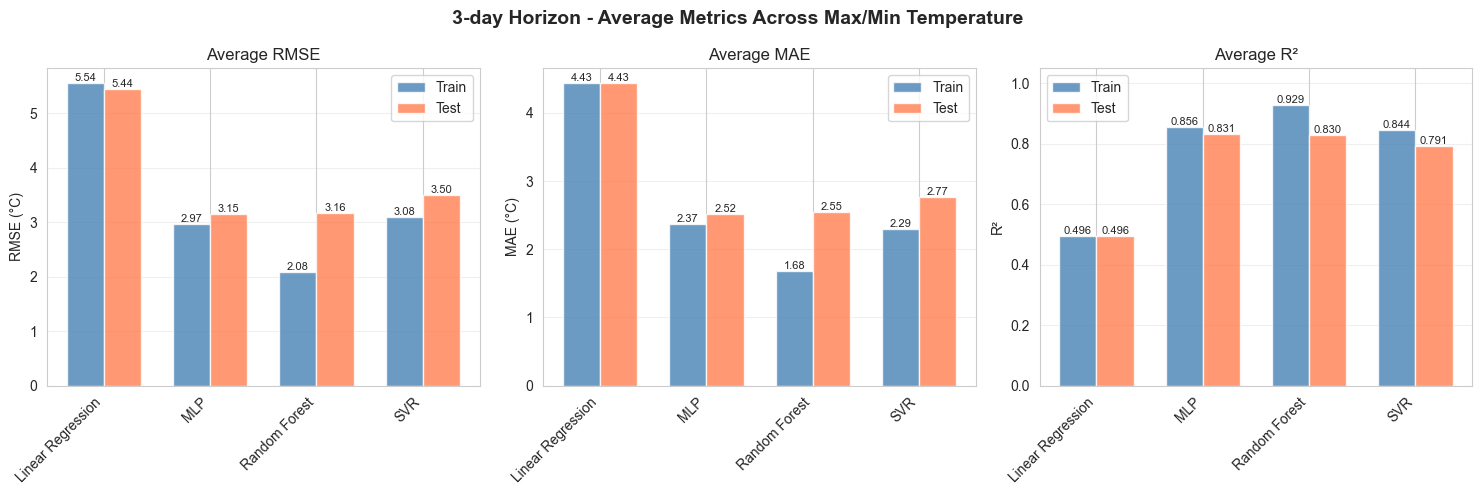


AVERAGE METRICS FOR 5-DAY HORIZON
                   Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
Model                                                                           
Linear Regression      5.6125     5.6108     4.4883    4.5450    0.4832   0.4661
MLP                    3.0832     3.2711     2.4729    2.6383    0.8438   0.8184
Random Forest          2.1982     3.3107     1.7708    2.6794    0.9208   0.8140
SVR                    3.2048     3.5823     2.3847    2.8475    0.8314   0.7821


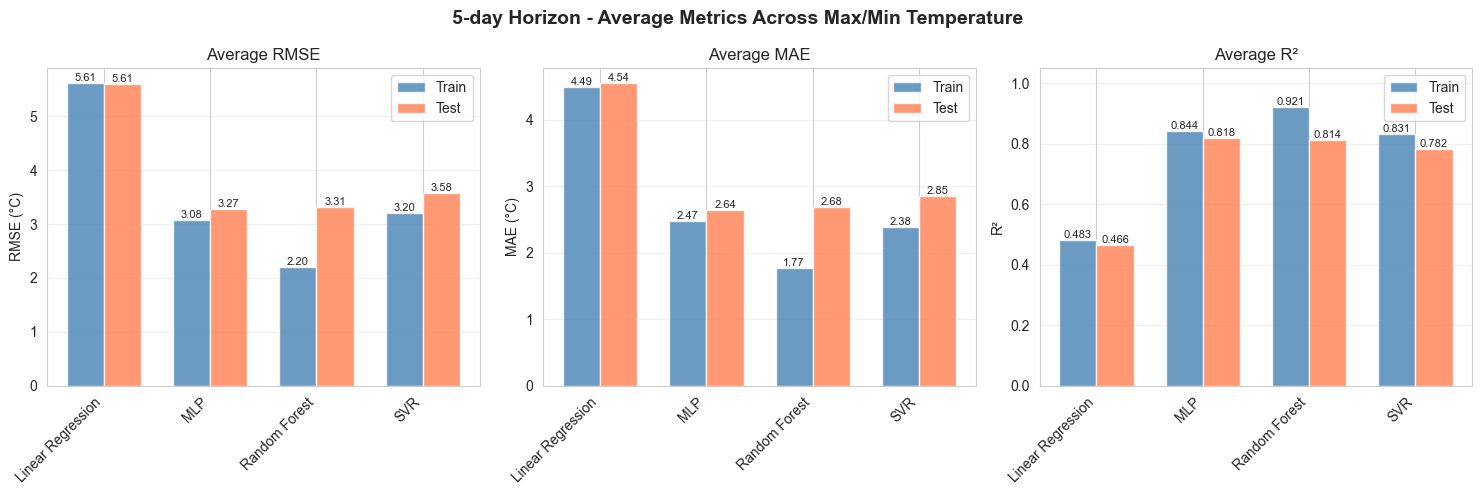


AVERAGE METRICS FOR 7-DAY HORIZON
                   Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
Model                                                                           
Linear Regression      5.6961     5.6505     4.5480    4.5516    0.4672   0.4597
MLP                    3.1837     3.3258     2.5582    2.6712    0.8332   0.8125
Random Forest          2.2273     3.4091     1.8062    2.7351    0.9186   0.8031
SVR                    3.1650     3.7123     2.3548    2.9528    0.8356   0.7665


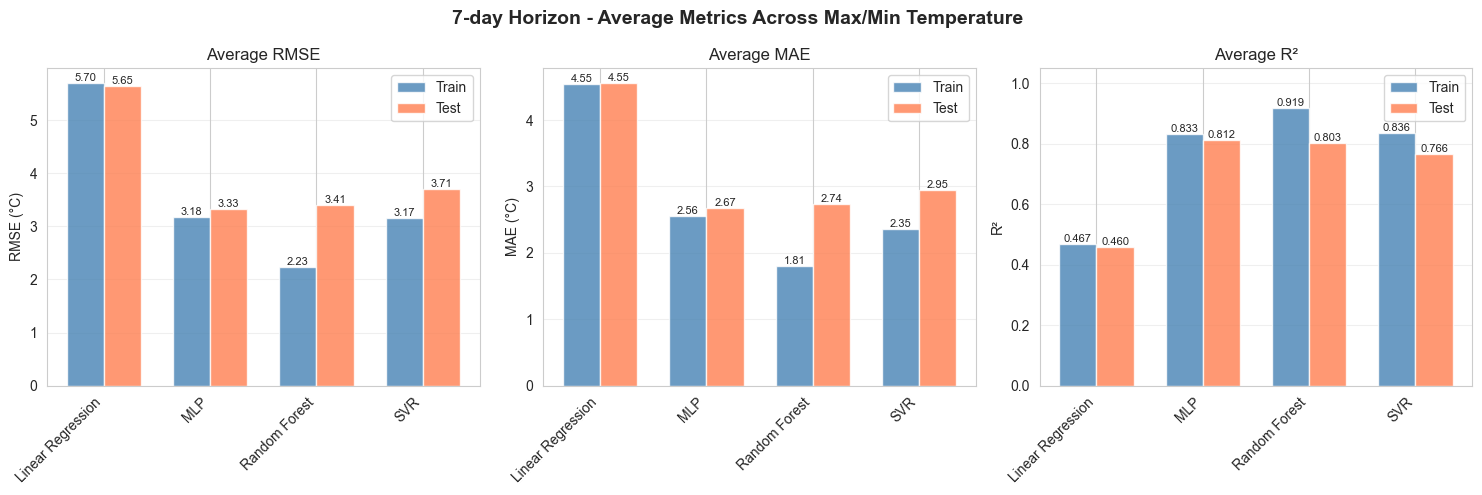


COMBINED SUMMARY TABLE - ALL HORIZONS

Horizon             Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
  3-day Linear Regression      5.5430     5.4389     4.4309    4.4306    0.4960   0.4964
  3-day               MLP      2.9659     3.1450     2.3743    2.5193    0.8557   0.8314
  3-day     Random Forest      2.0837     3.1640     1.6778    2.5452    0.9290   0.8297
  3-day               SVR      3.0836     3.4970     2.2918    2.7682    0.8443   0.7915
  5-day Linear Regression      5.6125     5.6108     4.4883    4.5450    0.4832   0.4661
  5-day               MLP      3.0832     3.2711     2.4729    2.6383    0.8438   0.8184
  5-day     Random Forest      2.1982     3.3107     1.7708    2.6794    0.9208   0.8140
  5-day               SVR      3.2048     3.5823     2.3847    2.8475    0.8314   0.7821
  7-day Linear Regression      5.6961     5.6505     4.5480    4.5516    0.4672   0.4597
  7-day               MLP      3.1837     3.3258     2.5582    2.6712 

In [48]:
# ============================================
# SUMMARY TABLE AND VISUALIZATION OF RESULTS
# ============================================

# Create summary tables and plots for each horizon
for horizon_name, data in results_by_horizon.items():
    results_df_h = data['results']
    
    # Calculate average metrics across Max/Min for each model
    avg_metrics = results_df_h.groupby('Model').agg({
        'Train RMSE': 'mean',
        'Test RMSE': 'mean',
        'Train MAE': 'mean',
        'Test MAE': 'mean',
        'Train R²': 'mean',
        'Test R²': 'mean'
    }).round(4)
    
    # Reorder columns for better readability
    avg_metrics = avg_metrics[['Train RMSE', 'Test RMSE', 'Train MAE', 'Test MAE', 'Train R²', 'Test R²']]
    
    # Print summary table
    print(f"\n{'='*60}")
    print(f"AVERAGE METRICS FOR {horizon_name.upper()} HORIZON")
    print(f"{'='*60}")
    print(avg_metrics.to_string())
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'{horizon_name} Horizon - Average Metrics Across Max/Min Temperature', fontsize=14, fontweight='bold')
    
    models = avg_metrics.index.tolist()
    x = np.arange(len(models))
    width = 0.35
    
    # Plot 1: RMSE
    ax1 = axes[0]
    bars1 = ax1.bar(x - width/2, avg_metrics['Train RMSE'], width, label='Train', color='steelblue', alpha=0.8)
    bars2 = ax1.bar(x + width/2, avg_metrics['Test RMSE'], width, label='Test', color='coral', alpha=0.8)
    ax1.set_ylabel('RMSE (°C)')
    ax1.set_title('Average RMSE')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    for bar in bars1:
        ax1.annotate(f'{bar.get_height():.2f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax1.annotate(f'{bar.get_height():.2f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=8)
    
    # Plot 2: MAE
    ax2 = axes[1]
    bars3 = ax2.bar(x - width/2, avg_metrics['Train MAE'], width, label='Train', color='steelblue', alpha=0.8)
    bars4 = ax2.bar(x + width/2, avg_metrics['Test MAE'], width, label='Test', color='coral', alpha=0.8)
    ax2.set_ylabel('MAE (°C)')
    ax2.set_title('Average MAE')
    ax2.set_xticks(x)
    ax2.set_xticklabels(models, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    for bar in bars3:
        ax2.annotate(f'{bar.get_height():.2f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=8)
    for bar in bars4:
        ax2.annotate(f'{bar.get_height():.2f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=8)
    
    # Plot 3: R²
    ax3 = axes[2]
    bars5 = ax3.bar(x - width/2, avg_metrics['Train R²'], width, label='Train', color='steelblue', alpha=0.8)
    bars6 = ax3.bar(x + width/2, avg_metrics['Test R²'], width, label='Test', color='coral', alpha=0.8)
    ax3.set_ylabel('R²')
    ax3.set_title('Average R²')
    ax3.set_xticks(x)
    ax3.set_xticklabels(models, rotation=45, ha='right')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    ax3.set_ylim(0, 1.05)
    for bar in bars5:
        ax3.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=8)
    for bar in bars6:
        ax3.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()

# ============================================
# COMBINED COMPARISON TABLE ACROSS ALL HORIZONS
# ============================================
print(f"\n{'='*80}")
print("COMBINED SUMMARY TABLE - ALL HORIZONS")
print(f"{'='*80}\n")

combined_results = []
for horizon_name, data in results_by_horizon.items():
    results_df_h = data['results']
    avg_metrics = results_df_h.groupby('Model').agg({
        'Train RMSE': 'mean',
        'Test RMSE': 'mean',
        'Train MAE': 'mean',
        'Test MAE': 'mean',
        'Train R²': 'mean',
        'Test R²': 'mean'
    }).round(4)
    avg_metrics['Horizon'] = horizon_name
    avg_metrics['Model'] = avg_metrics.index
    combined_results.append(avg_metrics)

combined_df = pd.concat(combined_results, ignore_index=True)
combined_df = combined_df[['Horizon', 'Model', 'Train RMSE', 'Test RMSE', 'Train MAE', 'Test MAE', 'Train R²', 'Test R²']]
print(combined_df.to_string(index=False))

### Compare Performance Across Horizons
**Comparing how accuracy changes with forecast horizon**


Horizon Best Model  Avg Test RMSE (°C)  Avg Test MAE (°C)  Avg Test R²
  3-day        MLP            3.144993           2.519254     0.831440
  5-day        MLP            3.271142           2.638254     0.818367
  7-day        MLP            3.325763           2.671193     0.812541


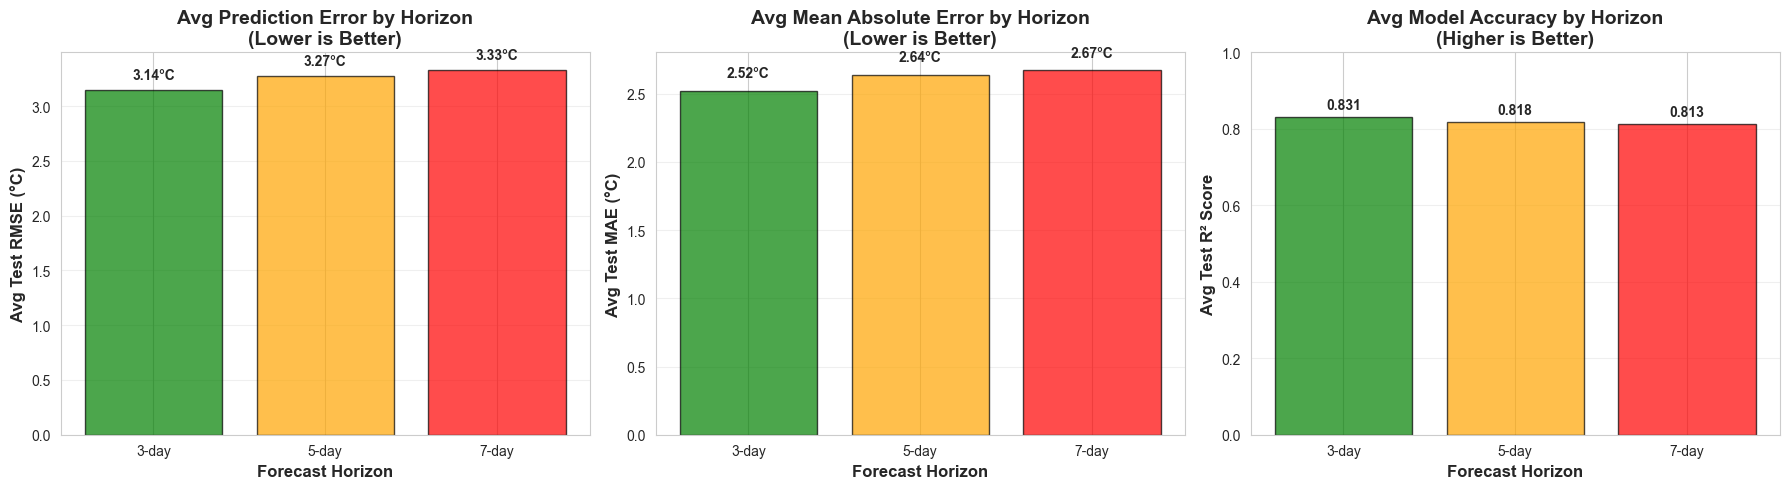

In [41]:
# Get best model for each horizon (using average RMSE across both Max and Min outputs)
comparison_data = []
for horizon_name in ['3-day', '5-day', '7-day']:
    results_df = results_by_horizon[horizon_name]['results']
    # Calculate average metrics across both outputs for each model
    avg_rmse = results_df.groupby('Model')['Test RMSE'].mean()
    avg_mae = results_df.groupby('Model')['Test MAE'].mean()
    avg_r2 = results_df.groupby('Model')['Test R²'].mean()
    # Find best model based on average RMSE
    best_model = avg_rmse.idxmin()
    
    comparison_data.append({
        'Horizon': horizon_name,
        'Best Model': best_model,
        'Avg Test RMSE (°C)': avg_rmse[best_model],
        'Avg Test MAE (°C)': avg_mae[best_model],
        'Avg Test R²': avg_r2[best_model]
    })

comparison_df = pd.DataFrame(comparison_data)
print('\n' + comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

horizons_list = ['3-day', '5-day', '7-day']
colors = ['green', 'orange', 'red']

# RMSE comparison
axes[0].bar(horizons_list, comparison_df['Avg Test RMSE (°C)'], color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Avg Test RMSE (°C)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Forecast Horizon', fontsize=12, fontweight='bold')
axes[0].set_title('Avg Prediction Error by Horizon\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['Avg Test RMSE (°C)']):
    axes[0].text(i, v + 0.1, f'{v:.2f}°C', ha='center', fontweight='bold')

# MAE comparison
axes[1].bar(horizons_list, comparison_df['Avg Test MAE (°C)'], color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Avg Test MAE (°C)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Forecast Horizon', fontsize=12, fontweight='bold')
axes[1].set_title('Avg Mean Absolute Error by Horizon\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['Avg Test MAE (°C)']):
    axes[1].text(i, v + 0.1, f'{v:.2f}°C', ha='center', fontweight='bold')

# R² comparison
axes[2].bar(horizons_list, comparison_df['Avg Test R²'], color=colors, alpha=0.7, edgecolor='black')
axes[2].set_ylabel('Avg Test R² Score', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Forecast Horizon', fontsize=12, fontweight='bold')
axes[2].set_title('Avg Model Accuracy by Horizon\n(Higher is Better)', fontsize=14, fontweight='bold')
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['Avg Test R²']):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [42]:
print('\n PART 1: SAME-TIME PREDICTION RESULTS (Multi-Output)')
print(f'Dataset: {df.shape[0]} samples, {len(features_to_keep)} features')
print(f'Targets: temp_max (°C), temp_min (°C)')
print(f'Training samples: {X_train.shape[0]} (2015-2022)')
print(f'Testing samples: {X_test.shape[0]} (2023-2025)')
print(f'\nBest Model (by avg RMSE): {results.loc[results["Avg Test RMSE"].idxmin(), "Model"]}')
print(f'Best Avg Test RMSE: {results["Avg Test RMSE"].min():.3f}°C')
print(f'Best Avg Test R²: {results.loc[results["Avg Test RMSE"].idxmin(), "Avg Test R²"]:.3f}')
print('\nPART 2: HORIZON FORECASTING RESULTS (Multi-Output)')

for horizon_name in ['3-day', '5-day', '7-day']:
    results_df = results_by_horizon[horizon_name]['results']
    # Find best model based on average RMSE across both outputs
    avg_rmse = results_df.groupby('Model')['Test RMSE'].mean()
    avg_r2 = results_df.groupby('Model')['Test R²'].mean()
    best_model = avg_rmse.idxmin()
    print(f'{horizon_name} forecast: {best_model} - Avg RMSE: {avg_rmse[best_model]:.3f}°C, Avg R²: {avg_r2[best_model]:.3f}')


 PART 1: SAME-TIME PREDICTION RESULTS (Multi-Output)
Dataset: 4018 samples, 9 features
Targets: temp_max (°C), temp_min (°C)
Training samples: 2922 (2015-2022)
Testing samples: 1096 (2023-2025)

Best Model (by avg RMSE): MLP (Neural Network)
Best Avg Test RMSE: 2.734°C
Best Avg Test R²: 0.872

PART 2: HORIZON FORECASTING RESULTS (Multi-Output)
3-day forecast: MLP - Avg RMSE: 3.145°C, Avg R²: 0.831
5-day forecast: MLP - Avg RMSE: 3.271°C, Avg R²: 0.818
7-day forecast: MLP - Avg RMSE: 3.326°C, Avg R²: 0.813
